# Pharma & Clinical Trials Analytics

## Project Overview

This project analyzes publicly available clinical trial data from ClinicalTrials.gov
to identify patterns and trends in pharmaceutical clinical research.

The analysis focuses on:

- Clinical development phases
- Therapeutic areas
- Study status
- Pharmaceutical and biotechnology interventions
- Sponsors
- Geographic distribution
- Study duration
- Patient enrollment

### Business Question

How does pharmaceutical clinical research evolve across therapeutic areas,
clinical development phases, sponsors, and geographic regions?

### Objective

The objective is to use data analytics techniques to identify relevant patterns
in clinical research activity and translate them into actionable insights.

### Tools

- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- Power BI

### Data Source

ClinicalTrials.gov — U.S. National Library of Medicine

In [1]:
import time
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import unicodedata 

from datetime import datetime


## Data Extraction

Clinical trial data were retrieved from the ClinicalTrials.gov API v2.

The analysis includes interventional studies involving drugs or biological
interventions with a start date between 2015 and 2025.

A local raw snapshot is used to preserve reproducibility.

In [2]:
API_URL = "https://clinicaltrials.gov/api/v2/studies"

QUERY = (
    "AREA[StudyType]INTERVENTIONAL AND "
    "(AREA[InterventionType]DRUG OR AREA[InterventionType]BIOLOGICAL) AND "
    "AREA[StartDate]RANGE[01/01/2015,12/31/2025]"
)

PAGE_SIZE = 1000

# Fixed extraction date for reproducibility
DATA_CUTOFF = pd.Timestamp("2026-09-03")

RAW_PATH = Path(
    "data/raw/clinical_trials_raw_2026-09-03.csv.gz"
)

In [3]:
#Crear función de extracciòn

def extract_trial_data(study):
    
    protocol = study.get("protocolSection", {})
    
    # Identification
    identification = protocol.get("identificationModule", {})
    
    # Status
    status = protocol.get("statusModule", {})
    
    # Sponsor
    sponsor = protocol.get("sponsorCollaboratorsModule", {})
    
    # Conditions
    conditions = protocol.get("conditionsModule", {})
    
    # Design
    design = protocol.get("designModule", {})
    
    # Interventions
    interventions = protocol.get("armsInterventionsModule", {})
    
    # Locations
    locations = protocol.get("contactsLocationsModule", {})
    
      # Conditions
    condition_list = conditions.get("conditions", [])
    
    # Interventions
    intervention_list = interventions.get("interventions", [])
    
    intervention_types = [
        intervention.get("type")
        for intervention in intervention_list
        if intervention.get("type")
    ]
    
    intervention_names = [
        intervention.get("name")
        for intervention in intervention_list
        if intervention.get("name")
    ]
    
    # Countries
    location_list = locations.get("locations", [])
    
    countries = [
        location.get("country")
        for location in location_list
        if location.get("country")
    ]
    
    trial = {
        "nct_id": identification.get("nctId"),
        "brief_title": identification.get("briefTitle"),
        "study_type": design.get("studyType"),
        "phase": design.get("phases", [None])[0] if design.get("phases") else None,
        "overall_status": status.get("overallStatus"),
        
        "conditions": "; ".join(condition_list) if condition_list else None,
        
        "sponsor_name": sponsor.get("leadSponsor", {}).get("name"),
        "sponsor_type": sponsor.get("leadSponsor", {}).get("class"),
        
        "start_date": status.get("startDateStruct", {}).get("date"),
        "completion_date": status.get("completionDateStruct", {}).get("date"),
        
        "enrollment": design.get("enrollmentInfo", {}).get("count"),
        
        "intervention_types": "; ".join(intervention_types) if intervention_types else None,
        "intervention_names": "; ".join(intervention_names) if intervention_names else None,
        
        "countries": "; ".join(sorted(set(countries))) if countries else None
    }
    
    return trial

In [4]:
session = requests.Session()


def get_page(params, max_retries=5, wait_seconds=5):
    """Request one API page with retry handling."""

    for attempt in range(1, max_retries + 1):

        try:
            response = session.get(
                API_URL,
                params=params,
                timeout=60
            )

            response.raise_for_status()

            return response.json()

        except requests.exceptions.RequestException:

            if attempt == max_retries:
                raise

            print(
                f"Connection error. "
                f"Retrying ({attempt}/{max_retries})..."
            )

            time.sleep(wait_seconds)

In [5]:
def download_clinical_trials():
    """Download all studies matching the project criteria."""

    trials = []
    seen_ids = set()
    next_page_token = None

    while True:

        params = {
            "query.term": QUERY,
            "pageSize": PAGE_SIZE,
            "format": "json"
        }

        if next_page_token:
            params["pageToken"] = next_page_token

        data = get_page(params)

        for study in data.get("studies", []):

            trial = extract_trial_data(study)
            nct_id = trial.get("nct_id")

            if nct_id and nct_id not in seen_ids:
                trials.append(trial)
                seen_ids.add(nct_id)

        print(f"Studies collected: {len(trials):,}")

        next_page_token = data.get("nextPageToken")

        if not next_page_token:
            break

        time.sleep(0.5)

    return pd.DataFrame(trials)

In [6]:
RAW_PATH.parent.mkdir(parents=True, exist_ok=True)

if RAW_PATH.exists():

    df_raw = pd.read_csv(
        RAW_PATH,
        compression="gzip"
    )

    print("Raw snapshot loaded.")

else:

    df_raw = download_clinical_trials()

    df_raw.to_csv(
        RAW_PATH,
        index=False,
        compression="gzip"
    )

    print("Raw snapshot created.")

print(f"Rows: {len(df_raw):,}")

Raw snapshot loaded.
Rows: 114,258


In [7]:
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")
print(f"Unique NCT IDs: {df_raw['nct_id'].nunique():,}")
print(f"Duplicate NCT IDs: {df_raw['nct_id'].duplicated().sum():,}")

Rows: 114,258
Columns: 14
Unique NCT IDs: 114,258
Duplicate NCT IDs: 0


## Data Quality & Cleaning

The raw dataset was assessed for missing values, duplicate trial identifiers,
data types, and consistency before analytical variables were created.

In [8]:
quality_summary = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_values": df_raw.isna().sum(),
    "missing_pct": (
        df_raw.isna().mean() * 100
    ).round(2)
})

display(quality_summary)

print(
    "Duplicate rows:",
    df_raw.duplicated().sum()
)

print(
    "Duplicate NCT IDs:",
    df_raw["nct_id"].duplicated().sum()
)

print("\nStudy types:")
print(df_raw["study_type"].value_counts())

,dtype,missing_values,missing_pct
nct_id,object,0,0.00
brief_title,object,0,0.00
study_type,object,0,0.00
phase,object,13268,11.61
overall_status,object,0,0.00
conditions,object,2,0.00
sponsor_name,object,0,0.00
sponsor_type,object,0,0.00
start_date,object,0,0.00
completion_date,object,377,0.33


Duplicate rows: 0
Duplicate NCT IDs: 0

Study types:
study_type
INTERVENTIONAL    114258
Name: count, dtype: int64


In [9]:
df_clean = df_raw.copy()

# Normalize empty text values
text_columns = [
    "brief_title",
    "conditions",
    "sponsor_name",
    "sponsor_type",
    "intervention_types",
    "intervention_names",
    "countries"
]

for column in text_columns:
    df_clean[column] = (
        df_clean[column]
        .replace(["", "None", "nan"], np.nan)
    )

# Convert mixed-format dates
df_clean["start_date"] = pd.to_datetime(
    df_clean["start_date"],
    format="mixed",
    errors="coerce"
)

df_clean["completion_date"] = pd.to_datetime(
    df_clean["completion_date"],
    format="mixed",
    errors="coerce"
)

# Convert enrollment to numeric
df_clean["enrollment"] = pd.to_numeric(
    df_clean["enrollment"],
    errors="coerce"
)

In [10]:
# Temporal variables
df_clean["start_year"] = df_clean["start_date"].dt.year
df_clean["completion_year"] = df_clean["completion_date"].dt.year

df_clean["duration_days"] = (
    df_clean["completion_date"]
    - df_clean["start_date"]
).dt.days

df_clean["duration_years"] = (
    df_clean["duration_days"] / 365.25
)

# Flag studies whose completion date is after the data cutoff
df_clean["future_completion"] = (
    df_clean["completion_date"] > DATA_CUTOFF
)

In [11]:
# Sponsor grouping
government_sponsor_types = [
    "NIH",
    "OTHER_GOV",
    "FED"
]

df_clean["sponsor_category"] = np.select(
    [
        df_clean["sponsor_type"].eq("INDUSTRY"),
        df_clean["sponsor_type"].isin(government_sponsor_types)
    ],
    [
        "Industry",
        "Government"
    ],
    default="Other"
)

# Standardize clinical phase labels
phase_map = {
    "EARLY_PHASE1": "Early Phase 1",
    "PHASE1": "Phase 1",
    "PHASE2": "Phase 2",
    "PHASE3": "Phase 3",
    "PHASE4": "Phase 4",
    "NA": "Not Applicable"
}

df_clean["phase_category"] = (
    df_clean["phase"]
    .map(phase_map)
    .fillna("Not Reported")
)

In [12]:
print("Rows:", f"{len(df_clean):,}")
print(
    "Unique NCT IDs:",
    f"{df_clean['nct_id'].nunique():,}"
)

print(
    "Valid start dates:",
    f"{df_clean['start_date'].notna().sum():,}"
)

print(
    "Missing completion dates:",
    f"{df_clean['completion_date'].isna().sum():,}"
)

print(
    "Negative durations:",
    (df_clean["duration_days"] < 0).sum()
)

print("\nSponsor categories:")
print(df_clean["sponsor_category"].value_counts())

print("\nClinical phases:")
print(
    df_clean["phase_category"]
    .value_counts(dropna=False)
)

Rows: 114,258
Unique NCT IDs: 114,258
Valid start dates: 114,258
Missing completion dates: 377
Negative durations: 0

Sponsor categories:
sponsor_category
Other         66502
Industry      43276
Government     4480
Name: count, dtype: int64

Clinical phases:
phase_category
Phase 2          32938
Phase 1          32652
Phase 3          16437
Phase 4          15170
Not Reported     13268
Early Phase 1     3793
Name: count, dtype: int64


## Sponsor and Clinical Phase Analysis

How are clinical trials distributed across development phases for each sponsor type?

Trials without a reported clinical phase are excluded from this phase-specific
comparison but remain part of the overall dataset.

In [13]:
clinical_phase_order = [
    "Early Phase 1",
    "Phase 1",
    "Phase 2",
    "Phase 3",
    "Phase 4"
]

df_phase_analysis = df_clean[
    df_clean["phase_category"].isin(clinical_phase_order)
].copy()

print(
    "Trials included in phase analysis:",
    f"{len(df_phase_analysis):,}"
)

print(
    "Trials excluded (phase not reported):",
    f"{(df_clean['phase_category'] == 'Not Reported').sum():,}"
)

Trials included in phase analysis: 100,990
Trials excluded (phase not reported): 13,268


In [14]:
phase_sponsor_count = pd.crosstab(
    df_phase_analysis["phase_category"],
    df_phase_analysis["sponsor_category"]
).reindex(clinical_phase_order)

phase_sponsor_pct = (
    phase_sponsor_count
    .div(phase_sponsor_count.sum(axis=0), axis=1)
    * 100
).round(2)

print("Number of trials:")
display(phase_sponsor_count)

print("\nDistribution within each sponsor (%):")
display(phase_sponsor_pct)

Number of trials:


sponsor_category,Government,Industry,Other
phase_category,,,
Early Phase 1,125,426,3242
Phase 1,1101,20307,11244
Phase 2,1457,10761,20720
Phase 3,475,9143,6819
Phase 4,644,1871,12655



Distribution within each sponsor (%):


sponsor_category,Government,Industry,Other
phase_category,,,
Early Phase 1,3.29,1.00,5.93
Phase 1,28.96,47.77,20.56
Phase 2,38.32,25.32,37.89
Phase 3,12.49,21.51,12.47
Phase 4,16.94,4.40,23.14


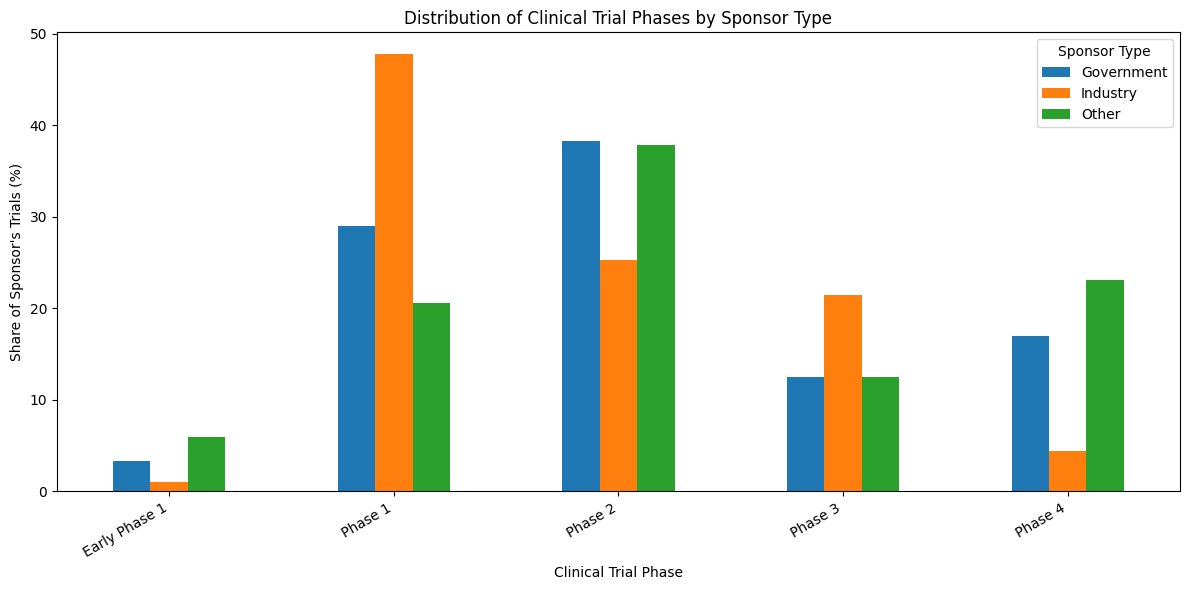

In [15]:
phase_sponsor_pct.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Distribution of Clinical Trial Phases by Sponsor Type"
)
plt.xlabel("Clinical Trial Phase")
plt.ylabel("Share of Sponsor's Trials (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sponsor Type")
plt.tight_layout()
plt.show()

### Key Insight

Clinical trial phase distributions differ substantially across sponsor types.

Industry-sponsored trials are strongly concentrated in Phase 1 (47.77%),
followed by Phase 2 (25.32%) and Phase 3 (21.51%). In contrast, Government
and Other sponsors show their largest concentration in Phase 2, representing
38.32% and 37.89% of their phase-reported trials, respectively.

Phase 4 represents a much larger share of trials among Other (23.14%) and
Government sponsors (16.94%) than among Industry sponsors (4.40%).

These results suggest distinct clinical development profiles across sponsor
types.

## Clinical Trial Trends Over Time

How has the number and relative share of clinical trials changed over time
across sponsor types?

Absolute trial counts show changes in activity, while annual percentage shares
show how the sponsor composition of clinical trials has evolved.

In [16]:
# Number of trials initiated each year by sponsor type
trials_by_year_sponsor = (
    df_clean
    .groupby(["start_year", "sponsor_category"])
    .size()
    .unstack(fill_value=0)
)

# Share of trials within each year
sponsor_share_by_year = (
    trials_by_year_sponsor
    .div(trials_by_year_sponsor.sum(axis=1), axis=0)
    * 100
)

print("Trials initiated by year:")
display(trials_by_year_sponsor)

print("\nAnnual sponsor share (%):")
display(sponsor_share_by_year.round(2))

Trials initiated by year:


sponsor_category,Government,Industry,Other
start_year,,,
2015,404,3605,5293
2016,402,3474,5521
2017,370,3398,5635
2018,411,3625,5610
2019,399,3717,5787
2020,440,3889,6319
2021,430,4753,6535
2022,389,4342,6079
2023,385,4119,6301



Annual sponsor share (%):


sponsor_category,Government,Industry,Other
start_year,,,
2015,4.34,38.76,56.90
2016,4.28,36.97,58.75
2017,3.93,36.14,59.93
2018,4.26,37.58,58.16
2019,4.03,37.53,58.44
2020,4.13,36.52,59.34
2021,3.67,40.56,55.77
2022,3.60,40.17,56.23
2023,3.56,38.12,58.32


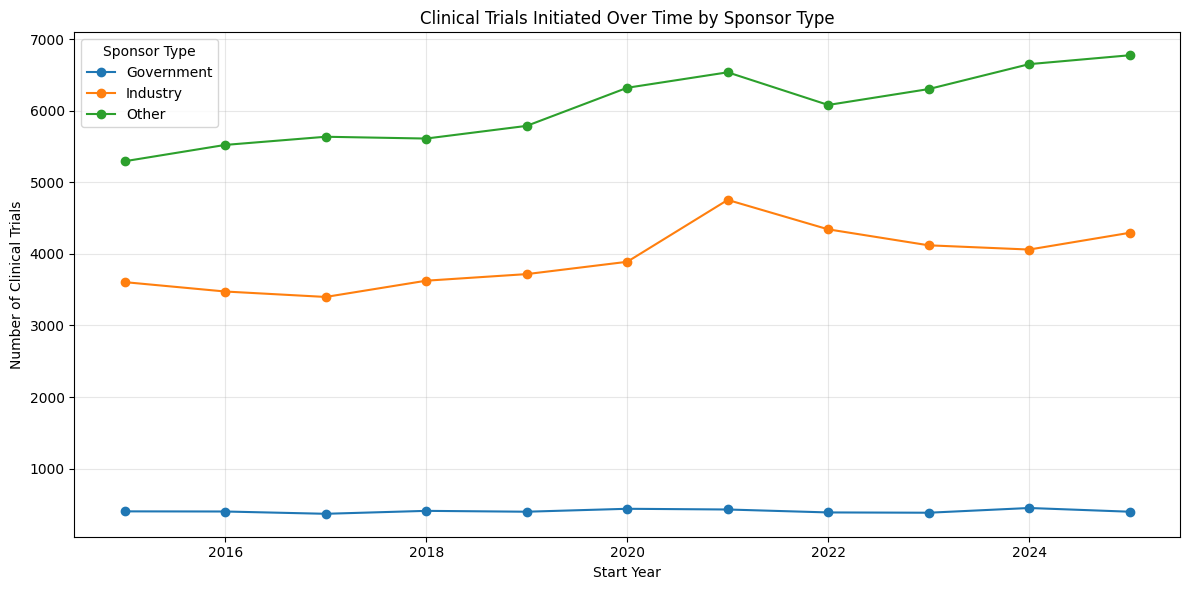

In [17]:
## Gráfica 1 — volumen absoluto
trials_by_year_sponsor.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

plt.title("Clinical Trials Initiated Over Time by Sponsor Type")
plt.xlabel("Start Year")
plt.ylabel("Number of Clinical Trials")
plt.legend(title="Sponsor Type")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

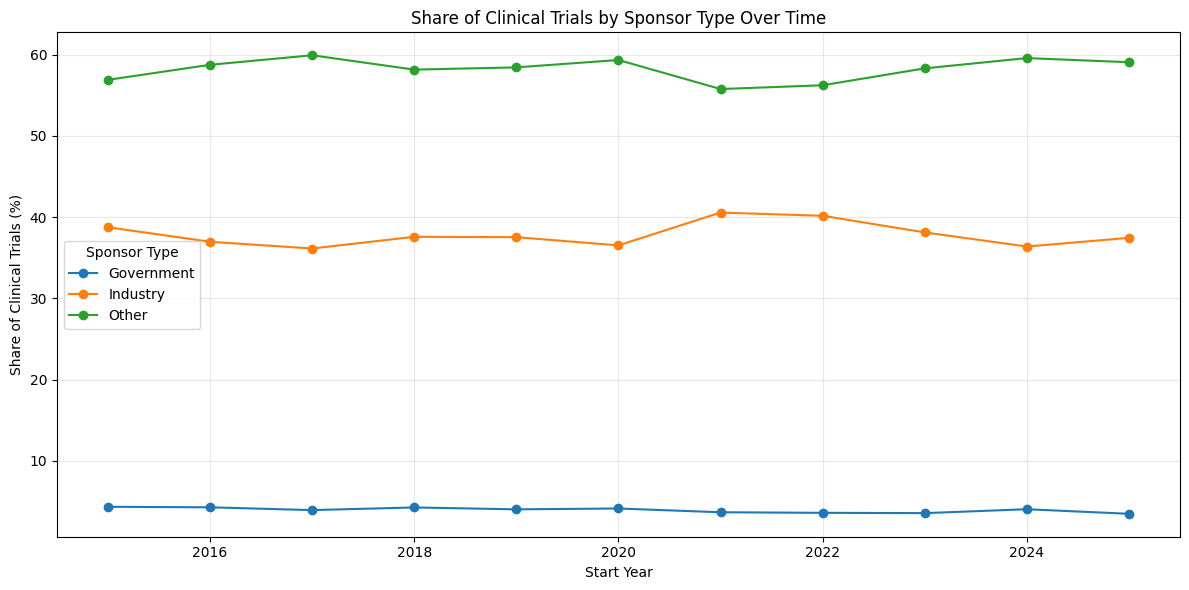

In [18]:
##Gráfica 2 — participación relativa
sponsor_share_by_year.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

plt.title("Share of Clinical Trials by Sponsor Type Over Time")
plt.xlabel("Start Year")
plt.ylabel("Share of Clinical Trials (%)")
plt.legend(title="Sponsor Type")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Key Insight

Other sponsors accounted for the largest share of newly initiated clinical
trials throughout the 2015–2025 period, remaining between approximately
56% and 60% of annual trial starts.

Industry represented roughly 36%–41% of annual starts, with a temporary
increase in share during 2021–2022 before returning closer to previous
levels. Government-sponsored trials remained comparatively stable at around
3.5%–4.3% of annual trial starts.

Overall, the sponsor composition remained relatively stable across the
study period, with Other sponsors consistently representing the largest
share.

## Clinical Trial Duration Analysis

The analysis includes clinical trials initiated between 2015 and 2025. 
Although the data were retrieved in September 2026, trials initiated in 
2026 were excluded because the year was still incomplete. The extraction 
date was used only to distinguish observed completion dates from future 
estimated completion dates.

In [19]:
print("Studies with future completion dates:")
print(df_clean["future_completion"].value_counts())

print("\nStatus of studies with future completion dates:")
print(
    df_clean.loc[
        df_clean["future_completion"],
        "overall_status"
    ].value_counts()
)

Studies with future completion dates:
future_completion
False    90341
True     23917
Name: count, dtype: int64

Status of studies with future completion dates:
overall_status
RECRUITING                 13945
ACTIVE_NOT_RECRUITING       6167
NOT_YET_RECRUITING          2669
ENROLLING_BY_INVITATION      459
WITHDRAWN                    458
SUSPENDED                    219
Name: count, dtype: int64


In [20]:
# Create a dataset for observed duration analysis
df_duration = df_clean[
    (df_clean["overall_status"] == "COMPLETED") &
    (df_clean["start_date"].notna()) &
    (df_clean["completion_date"].notna()) &
    (df_clean["completion_date"] <= DATA_CUTOFF)
].copy()

print("Completed studies available:", len(df_duration))

print(
    "Completed studies excluded because of missing dates:",
    (
        (df_clean["overall_status"] == "COMPLETED") &
        (
            df_clean["start_date"].isna() |
            df_clean["completion_date"].isna()
        )
    ).sum()
)

print("\nDuration summary for completed studies:")
print(df_duration["duration_years"].describe())

print(
    "\nCompleted studies lasting more than 20 years:",
    (df_duration["duration_years"] > 20).sum()
)

print(
    "Completed studies with zero duration:",
    (df_duration["duration_days"] == 0).sum()
)

Completed studies available: 51138
Completed studies excluded because of missing dates: 62

Duration summary for completed studies:
count    51138.000000
mean         2.084770
std          1.826703
min          0.000000
25%          0.695414
50%          1.538672
75%          2.962355
max         11.340178
Name: duration_years, dtype: float64

Completed studies lasting more than 20 years: 0
Completed studies with zero duration: 59


### Zero-Duration Validation

Completed trials with a calculated duration of zero days were reviewed to
distinguish true same-day studies from cases caused by incomplete date
precision.

In [21]:
# Inspect completed studies with zero duration
zero_duration = df_duration[
    df_duration["duration_days"] == 0
][
    [
        "nct_id",
        "brief_title",
        "phase_category",
        "start_date",
        "completion_date",
        "enrollment"
    ]
].copy()

# Recover the original date strings for validation
zero_duration["raw_start_date"] = df_raw.loc[
    zero_duration.index,
    "start_date"
]

zero_duration["raw_completion_date"] = df_raw.loc[
    zero_duration.index,
    "completion_date"
]

print("Zero-duration studies:", len(zero_duration))

zero_duration[
    [
        "nct_id",
        "phase_category",
        "raw_start_date",
        "raw_completion_date",
        "enrollment"
    ]
].head(20)

Zero-duration studies: 59


,nct_id,phase_category,raw_start_date,raw_completion_date,enrollment
4911,NCT02859259,Phase 1,2016-08-12,2016-08-12,14.0
5872,NCT04555798,Phase 1,2022-02-01,2022-02-01,100.0
6175,NCT02597400,Phase 1,2015-10,2015-10,12.0
6461,NCT02854137,Not Reported,2015-10-14,2015-10-14,23.0
11990,NCT07266532,Not Reported,2025-12-15,2025-12-15,98.0
12797,NCT02123290,Phase 2,2016-01,2016-01,45.0
13143,NCT02667106,Phase 1,2015-10,2015-10,30.0
14248,NCT02334943,Not Reported,2015-03,2015-03,140.0
14318,NCT02381418,Phase 3,2015-03,2015-03,120.0
14765,NCT03959176,Phase 4,2019-07-20,2019-07-20,13.0


In [22]:
#Contemos cuántos de los 59 casos pertenecen a cada tipo de precisión
# Classify the precision of the original dates
precision_map = {
    10: "Day",
    7: "Month",
    4: "Year"
}

zero_duration["start_date_precision"] = (
    zero_duration["raw_start_date"]
    .astype(str)
    .str.len()
    .map(precision_map)
    .fillna("Other")
)

zero_duration["completion_date_precision"] = (
    zero_duration["raw_completion_date"]
    .astype(str)
    .str.len()
    .map(precision_map)
    .fillna("Other")
)

pd.crosstab(
    zero_duration["start_date_precision"],
    zero_duration["completion_date_precision"]
)

completion_date_precision,Day,Month
start_date_precision,,
Day,22,0
Month,0,37


In [23]:
# Identify zero durations caused by month-level date precision
ambiguous_zero_indices = zero_duration[
    (zero_duration["start_date_precision"] == "Month") &
    (zero_duration["completion_date_precision"] == "Month")
].index

# Final dataset for duration analysis
df_duration_analysis = df_duration.drop(
    index=ambiguous_zero_indices
).copy()

print("Studies in duration analysis:", len(df_duration_analysis))
print(
    "Exact same-day studies retained:",
    (df_duration_analysis["duration_days"] == 0).sum()
)

print("\nFinal duration summary:")
print(df_duration_analysis["duration_years"].describe())

Studies in duration analysis: 51101
Exact same-day studies retained: 22

Final duration summary:
count    51101.000000
mean         2.086279
std          1.826502
min          0.000000
25%          0.695414
50%          1.541410
75%          2.965092
max         11.340178
Name: duration_years, dtype: float64


Of the 59 completed trials initially showing zero-day duration, 37 had
start and completion dates reported only at month-level precision. These
records were excluded from duration analysis because their true duration
could not be determined reliably.

The remaining 22 trials had complete day-level dates and were retained as
valid same-day studies.

In [24]:
# Summarize trial duration by clinical phase
duration_by_phase = (
    df_duration_analysis
    .groupby("phase_category")["duration_years"]
    .agg(
        studies="count",
        mean_years="mean",
        median_years="median",
        q1_years=lambda x: x.quantile(0.25),
        q3_years=lambda x: x.quantile(0.75)
    )
    .reindex(clinical_phase_order)
    .round(2)
)

duration_by_phase

,studies,mean_years,median_years,q1_years,q3_years
phase_category,,,,,
Early Phase 1,1382,2.19,1.72,0.88,3.09
Phase 1,16695,1.68,0.97,0.36,2.42
Phase 2,12261,2.62,2.10,1.12,3.67
Phase 3,7559,2.49,1.99,1.11,3.38
Phase 4,7159,2.04,1.65,0.87,2.77


### Key Insight

Trial duration varies across clinical development phases.

Phase 2 trials showed the longest median duration at 2.10 years, followed by
Phase 3 at 1.99 years. Early Phase 1 and Phase 4 trials had median durations
of 1.72 and 1.65 years, respectively, while Phase 1 trials had the shortest
median duration at 0.97 years.

Across all phases, mean duration was higher than median duration, indicating
that longer-running trials influence the average. For this reason, median
duration provides a more representative measure of typical trial length.

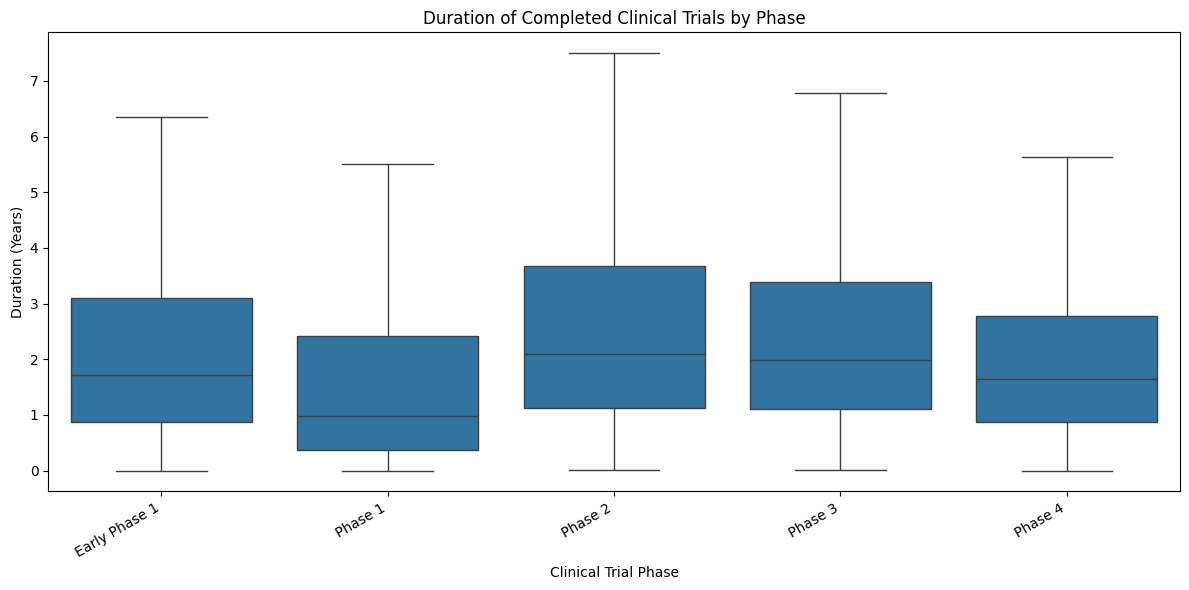

In [25]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_duration_analysis[
        df_duration_analysis["phase_category"].isin(clinical_phase_order)
    ],
    x="phase_category",
    y="duration_years",
    order=clinical_phase_order,
    showfliers=False
)

plt.title("Duration of Completed Clinical Trials by Phase")
plt.xlabel("Clinical Trial Phase")
plt.ylabel("Duration (Years)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Key Insight

Among completed clinical trials, Phase 2 studies had the longest typical
duration, with a median of 2.10 years, followed by Phase 3 studies at
1.99 years. Phase 1 trials had the shortest median duration among the
defined clinical phases, at 0.97 years.

Trial duration did not increase uniformly across successive development
phases, indicating distinct duration patterns across clinical phases.

### Trial Duration by Phase and Sponsor Type

How does the median duration of completed clinical trials vary by sponsor type within each clinical phase?

In [26]:
sponsor_order = [
    "Industry",
    "Government",
    "Other"
]

duration_phase_sponsor = df_duration_analysis[
    df_duration_analysis["phase_category"].isin(clinical_phase_order)
].copy()

median_duration_phase_sponsor = (
    pd.pivot_table(
        duration_phase_sponsor,
        index="phase_category",
        columns="sponsor_category",
        values="duration_years",
        aggfunc="median"
    )
    .reindex(
        index=clinical_phase_order,
        columns=sponsor_order
    )
    .round(2)
)

count_duration_phase_sponsor = (
    pd.pivot_table(
        duration_phase_sponsor,
        index="phase_category",
        columns="sponsor_category",
        values="duration_years",
        aggfunc="count"
    )
    .reindex(
        index=clinical_phase_order,
        columns=sponsor_order
    )
    .fillna(0)
    .astype(int)
)

print("Median duration in years:")
display(median_duration_phase_sponsor)

print("\nNumber of completed studies:")
display(count_duration_phase_sponsor)

Median duration in years:


sponsor_category,Industry,Government,Other
phase_category,,,
Early Phase 1,0.77,1.82,1.84
Phase 1,0.68,2.13,2.32
Phase 2,1.63,2.72,2.67
Phase 3,1.89,2.00,2.24
Phase 4,1.50,1.52,1.67



Number of completed studies:


sponsor_category,Industry,Government,Other
phase_category,,,
Early Phase 1,137,49,1196
Phase 1,12119,481,4095
Phase 2,5546,456,6259
Phase 3,5074,185,2300
Phase 4,1181,284,5694


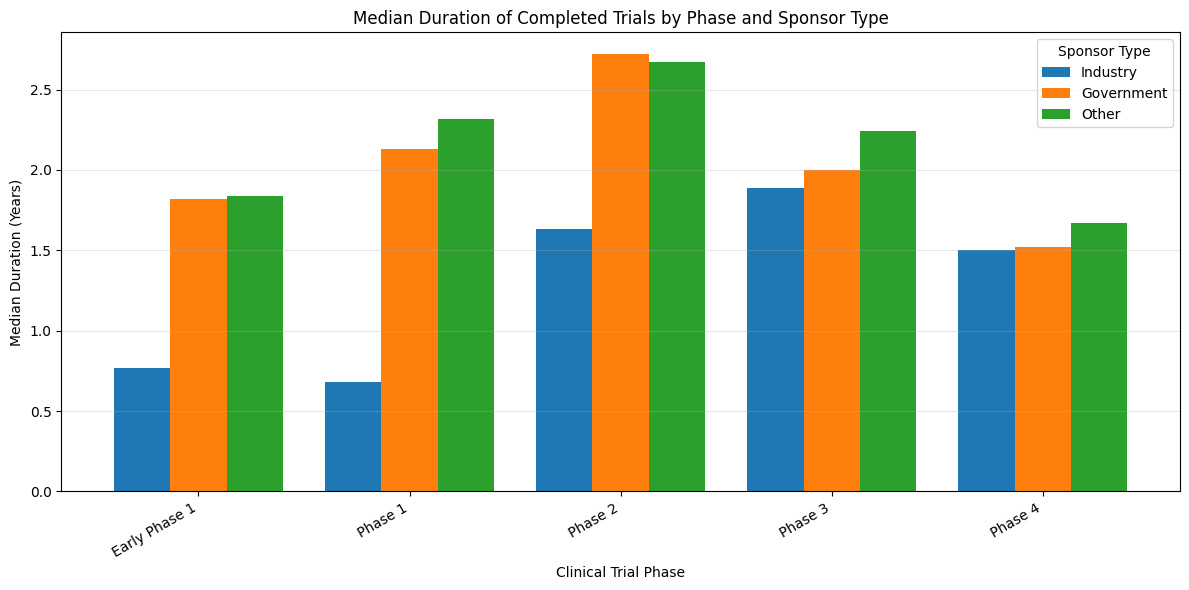

In [27]:
median_duration_phase_sponsor.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title("Median Duration of Completed Trials by Phase and Sponsor Type")
plt.xlabel("Clinical Trial Phase")
plt.ylabel("Median Duration (Years)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sponsor Type")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Key Insight

Industry-sponsored completed trials showed shorter median durations than
Government and Other sponsors across all defined clinical phases.

The largest differences were observed in Phase 1 and Phase 2. In Phase 1,
the median duration was 0.68 years for Industry-sponsored trials, compared
with 2.13 years for Government and 2.32 years for Other sponsors. In Phase 2,
Industry trials had a median duration of 1.63 years, compared with 2.72 and
2.67 years for Government and Other sponsors, respectively.

Differences were smaller in later phases, particularly Phase 3 and Phase 4.
Because sponsor groups contain different numbers of completed trials, both
median duration and study counts should be considered when interpreting
these comparisons.

## Exploring the “Other” Sponsor Category

The registry-level “Other” sponsor category includes a heterogeneous group
of organizations. Sponsor names were therefore used to create a more detailed
heuristic classification for analytical purposes.

This classification does not replace the original ClinicalTrials.gov sponsor
type and should be interpreted as an analytical grouping based on organization
name patterns.

In [28]:
# Create a subset containing studies classified as Other
df_other = df_clean[
    df_clean["sponsor_category"] == "Other"
].copy()

print(
    "Studies classified as Other:",
    f"{len(df_other):,}"
)

print("\nOriginal sponsor types within Other:")
print(
    df_other["sponsor_type"]
    .value_counts(dropna=False)
)

print(
    "\nUnique sponsor names:",
    f"{df_other['sponsor_name'].nunique():,}"
)

Studies classified as Other: 66,502

Original sponsor types within Other:
sponsor_type
OTHER      65635
NETWORK      778
INDIV         61
UNKNOWN       28
Name: count, dtype: int64

Unique sponsor names: 9,864


In [29]:

def normalize_sponsor_name(name):
    name = str(name).upper()
    
    return (
        unicodedata.normalize("NFKD", name)
        .encode("ascii", "ignore")
        .decode("utf-8")
    )


def classify_other_sponsor(row):
    
    sponsor_type = row["sponsor_type"]
    name = normalize_sponsor_name(row["sponsor_name"])
    
    # Preserve explicit registry classifications
    if sponsor_type == "NETWORK":
        return "Network / Consortium"
    
    if sponsor_type == "INDIV":
        return "Individual"
    
    if sponsor_type == "UNKNOWN":
        return "Unknown"
    
    academic_keywords = [
        "UNIVERSIT",
        "UNIVERSIDAD",
        "UNIVERSIDADE",
        "COLLEGE",
        "SCHOOL OF",
        "ACADEMY"
    ]
    
    if any(keyword in name for keyword in academic_keywords):
        return "Academic Institution"
    
    research_keywords = [
        "RESEARCH INSTITUTE",
        "RESEARCH CENTER",
        "RESEARCH CENTRE",
        "CANCER RESEARCH",
        "INSTITUTE",
        "INSTITUT",
        "INSTITUTO",
        "IRCCS"
    ]
    
    if any(keyword in name for keyword in research_keywords):
        return "Research Institute"
    
    healthcare_keywords = [
        "HOSPITAL",
        "HOSPICE",
        "HOPITAUX",
        "HOPITAL",
        "CLINIC",
        "MEDICAL CENTER",
        "MEDICAL CENTRE",
        "MEDICAL ORGANIZATION",
        "HEALTH",
        "HEALTHCARE",
        "HEALTH CARE",
        "CANCER CENTER",
        "CANCER CENTRE",
        "CANCER CAMPUS",
        "CENTRE HOSPITALIER",
        "KLINIK",
        "OSPEDALE",
        "UMC"
    ]
    
    if any(keyword in name for keyword in healthcare_keywords):
        return "Hospital / Healthcare"
    
    nonprofit_keywords = [
        "FOUNDATION",
        "FUNDACION",
        "FUNDACAO",
        "FONDAZIONE",
        "ASSOCIATION",
        "SOCIETY",
        "CHARITY",
        "TRUST"
    ]
    
    if any(keyword in name for keyword in nonprofit_keywords):
        return "Foundation / Nonprofit"
    
    network_keywords = [
        "NETWORK",
        "CONSORTIUM",
        "COOPERATIVE GROUP"
    ]
    
    if any(keyword in name for keyword in network_keywords):
        return "Network / Consortium"
    
    private_keywords = [
        "CO., LTD",
        "CO. LTD",
        "CORPORATION",
        " LLC",
        " GMBH",
        "BIOSCIENCE",
        "BIOTECH",
        "PHARMA",
        "THERAPEUTICS"
    ]
    
    if any(keyword in name for keyword in private_keywords):
        return "Private Organization"
    
    return "Other / Unclassified"


df_other["detailed_sponsor_category"] = df_other.apply(
    classify_other_sponsor,
    axis=1
)

print("Refined classification:")
print(
    df_other["detailed_sponsor_category"]
    .value_counts()
)


Refined classification:
detailed_sponsor_category
Academic Institution      35389
Hospital / Healthcare     14625
Other / Unclassified       9897
Research Institute         4332
Network / Consortium        869
Foundation / Nonprofit      727
Private Organization        574
Individual                   61
Unknown                      28
Name: count, dtype: int64


In [30]:
# Distribution of detailed sponsor categories
detailed_sponsor_summary = (
    df_other["detailed_sponsor_category"]
    .value_counts()
    .rename_axis("detailed_sponsor_category")
    .reset_index(name="studies")
)

detailed_sponsor_summary["percentage"] = (
    detailed_sponsor_summary["studies"]
    / len(df_other)
    * 100
).round(2)

detailed_sponsor_summary

,detailed_sponsor_category,studies,percentage
0,Academic Institution,35389,53.21
1,Hospital / Healthcare,14625,21.99
2,Other / Unclassified,9897,14.88
3,Research Institute,4332,6.51
4,Network / Consortium,869,1.31
5,Foundation / Nonprofit,727,1.09
6,Private Organization,574,0.86
7,Individual,61,0.09
8,Unknown,28,0.04


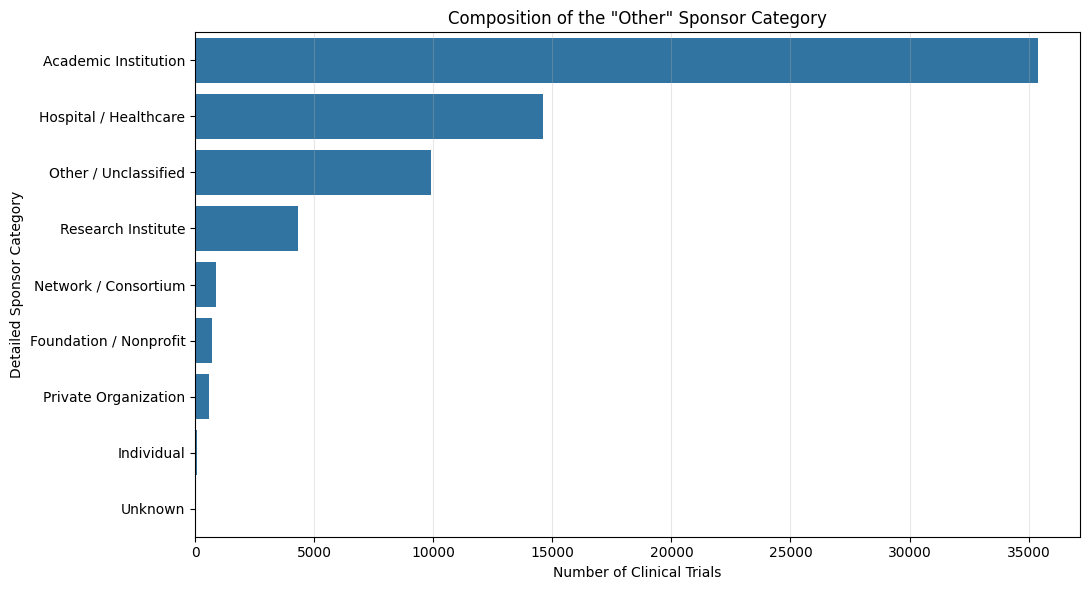

In [31]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=detailed_sponsor_summary,
    x="studies",
    y="detailed_sponsor_category"
)

plt.title('Composition of the "Other" Sponsor Category')
plt.xlabel("Number of Clinical Trials")
plt.ylabel("Detailed Sponsor Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Key Insight

The registry-level “Other” sponsor category was primarily composed of
academic institutions (53.21%), hospitals and healthcare organizations
(21.99%), and research institutes (6.51%). Together, these groups accounted
for 81.71% of trials within the category.

This shows that “Other” largely represents academic and healthcare-led
clinical research rather than a single homogeneous sponsor type.

The detailed classification is heuristic and based on sponsor-name patterns;
14.88% of studies remained unclassified to avoid unsupported assumptions.

## Clinical Trial Status Analysis
This section examines the current status of clinical trials and identifies 
differences in completion and discontinuation across sponsor types and 
clinical phases.

In [32]:
# Group registry statuses into broader analytical categories
status_group_map = {
    "COMPLETED": "Completed",
    
    "RECRUITING": "Ongoing",
    "ACTIVE_NOT_RECRUITING": "Ongoing",
    "ENROLLING_BY_INVITATION": "Ongoing",
    
    "NOT_YET_RECRUITING": "Not Started",
    
    "TERMINATED": "Discontinued",
    "WITHDRAWN": "Discontinued",
    "SUSPENDED": "Discontinued",
    
    "UNKNOWN": "Unknown"
}

df_clean["status_group"] = df_clean["overall_status"].map(
    status_group_map
)

# Validate that every original status was classified
print(
    "Unclassified statuses:",
    df_clean["status_group"].isna().sum()
)

status_summary = (
    df_clean["status_group"]
    .value_counts()
    .rename_axis("status_group")
    .reset_index(name="studies")
)

status_summary["percentage"] = (
    status_summary["studies"]
    / len(df_clean)
    * 100
).round(2)

status_summary

Unclassified statuses: 0


,status_group,studies,percentage
0,Completed,51200,44.81
1,Ongoing,24991,21.87
2,Unknown,20064,17.56
3,Discontinued,14618,12.79
4,Not Started,3385,2.96


Completed studies represented 44.81% of the dataset, while 21.87% were 
ongoing and 12.79% had been discontinued. An additional 17.56% had an 
unknown status, representing an important limitation when interpreting 
overall trial outcomes.

In [33]:
# Include only trials with a known final outcome
df_final_outcome = df_clean[
    df_clean["status_group"].isin(
        ["Completed", "Discontinued"]
    )
].copy()

# Counts by sponsor and final outcome
final_outcome_counts = pd.crosstab(
    df_final_outcome["sponsor_category"],
    df_final_outcome["status_group"]
).reindex(
    index=["Industry", "Government", "Other"],
    columns=["Completed", "Discontinued"]
)

# Percentages within trials with a known final outcome
final_outcome_pct = (
    pd.crosstab(
        df_final_outcome["sponsor_category"],
        df_final_outcome["status_group"],
        normalize="index"
    ) * 100
).reindex(
    index=["Industry", "Government", "Other"],
    columns=["Completed", "Discontinued"]
).round(2)

print("Final outcome counts:")
display(final_outcome_counts)

print("\nFinal outcome percentages:")
display(final_outcome_pct)

Final outcome counts:


status_group,Completed,Discontinued
sponsor_category,,
Industry,24533,6135
Government,1780,461
Other,24887,8022



Final outcome percentages:


status_group,Completed,Discontinued
sponsor_category,,
Industry,80.00,20.00
Government,79.43,20.57
Other,75.62,24.38


Among trials with a known final outcome, Industry and Government-sponsored 
studies had similar completion rates of 80.00% and 79.43%, respectively. 
Trials sponsored by Other organizations had a lower completion rate of 
75.62% and a discontinuation rate of 24.38%, approximately four percentage 
points higher than the other sponsor groups. These differences are 
descriptive and may also reflect variation in clinical phase, therapeutic 
area, and study design.

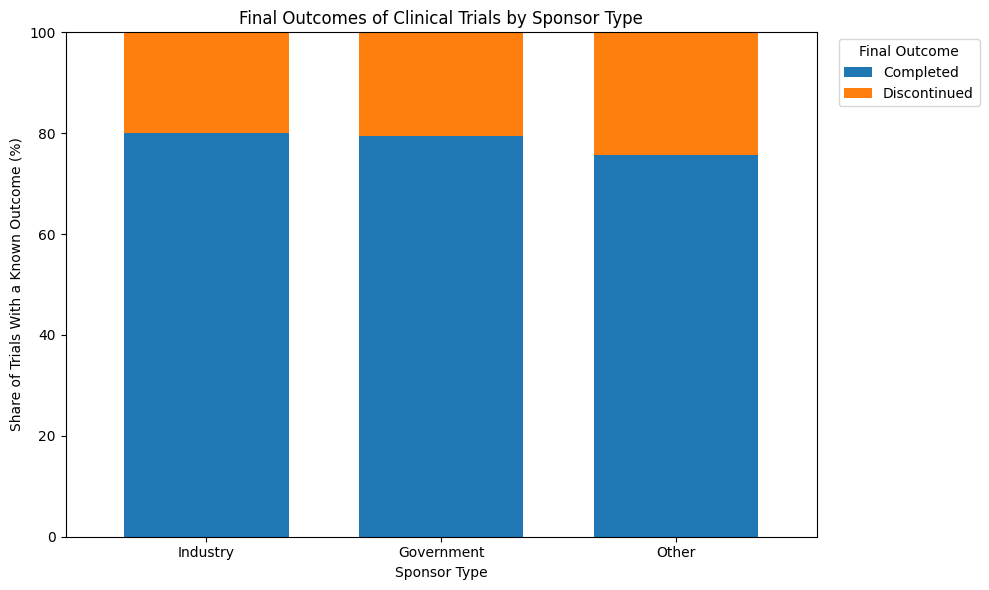

In [34]:
final_outcome_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.7
)

plt.title("Final Outcomes of Clinical Trials by Sponsor Type")
plt.xlabel("Sponsor Type")
plt.ylabel("Share of Trials With a Known Outcome (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Final Outcome",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Key Insight

Among trials with a known final outcome, Industry and Government-sponsored
studies showed similar completion rates, at approximately 80%.

Trials sponsored by Other organizations had a lower completion rate and a
correspondingly higher share of discontinued trials.

These comparisons are descriptive and include only trials with a known final
outcome. Differences may also reflect variation in clinical phase,
therapeutic area, and study characteristics.

## Therapeutic Area Analysis

Clinical trials may include multiple medical conditions. This section 
standardizes individual condition records and groups them into broader 
therapeutic areas for analysis.

In [35]:
# Create one row per trial and medical condition
df_conditions = (
    df_clean[
        ["nct_id", "conditions"]
    ]
    .dropna(subset=["conditions"])
    .assign(
        condition=lambda x: x["conditions"].str.split(";")
    )
    .explode("condition")
)

# Clean condition text
df_conditions["condition"] = (
    df_conditions["condition"]
    .str.strip()
)

# Remove empty values and repeated conditions within the same trial
df_conditions = (
    df_conditions[
        df_conditions["condition"].ne("")
    ]
    .drop_duplicates(
        subset=["nct_id", "condition"]
    )
)

# Normalize condition names for keyword matching
df_conditions["condition_normalized"] = (
    df_conditions["condition"]
    .apply(normalize_sponsor_name)
)

conditions_per_trial = (
    df_conditions
    .groupby("nct_id")
    .size()
)

print(
    "Condition records:",
    f"{len(df_conditions):,}"
)

print(
    "Unique condition terms:",
    f"{df_conditions['condition'].nunique():,}"
)

print(
    "Trials with multiple conditions:",
    f"{(conditions_per_trial > 1).sum():,}"
)

Condition records: 204,071
Unique condition terms: 40,937
Trials with multiple conditions: 37,433


In [36]:
# Ordered keyword dictionary
therapeutic_keywords = {
    "Healthy Volunteers": [
        "HEALTHY"
    ],
    
    "Oncology": [
        "CANCER", "CARCINOMA", "TUMOR", "TUMOUR",
        "LEUKEMIA", "LYMPHOMA", "MELANOMA",
        "MYELOMA", "NEOPLASM", "SARCOMA",
        "GLIOBLASTOMA", "MYELODYSPLASTIC", "NSCLC"
    ],
    
    "Infectious Diseases": [
        "COVID", "SARS-COV", "INFECTION", "INFECTIOUS",
        "HIV", "AIDS", "TUBERCULOSIS", "MALARIA",
        "HEPATITIS", "INFLUENZA", "VIRAL", "VIRUS",
        "BACTERIAL", "BACTERIA", "PARASIT",
        "SEPSIS", "SEPTIC"
    ],
    
    "Neurology / Mental Health": [
        "ALZHEIMER", "PARKINSON", "EPILEP",
        "STROKE", "MIGRAINE", "NEURO",
        "DEPRESSION", "DEPRESSIVE", "ANXIETY",
        "SCHIZOPHRENIA", "BIPOLAR", "DEMENTIA",
        "MULTIPLE SCLEROSIS", "AMYOTROPHIC",
        "ALCOHOL USE", "OPIOID USE",
        "SUBSTANCE USE", "ADDICTION",
        "SMOKING CESSATION"
    ],
    
    "Cardiovascular": [
        "CARDIAC", "CARDIOVASCULAR", "CORONARY",
        "HYPERTENSION", "HEART FAILURE",
        "HEART DISEASE", "MYOCARDIAL",
        "ATRIAL FIBRILLATION", "ATHEROSCLEROSIS"
    ],
    
    "Metabolic / Endocrine": [
        "DIABET", "OBESITY", "OVERWEIGHT",
        "METABOLIC", "THYROID", "ENDOCRIN",
        "HYPERGLYCEMIA", "DYSLIPIDEMIA",
        "HYPERLIPIDEMIA"
    ],
    
    "Respiratory": [
        "ASTHMA", "COPD", "PULMONARY",
        "RESPIRATORY", "BRONCH", "CYSTIC FIBROSIS"
    ],
    
    "Immune / Inflammatory": [
        "AUTOIMMUNE", "INFLAMMATORY", "INFLAMMATION",
        "ARTHRITIS", "LUPUS", "PSORIASIS",
        "CROHN", "ULCERATIVE COLITIS",
        "ALLERGY", "ALLERGIC",
        "DERMATITIS", "ECZEMA", "ACNE"
    ],
    
    "Hematology": [
        "ANEMIA", "SICKLE CELL", "HEMOPHIL",
        "THROMBO", "HEMATOLOG"
    ],
    
    "Renal / Urologic": [
        "KIDNEY", "RENAL", "NEPHR",
        "DIALYSIS", "UROLOG"
    ],
    
    "Reproductive Health": [
        "INFERTIL", "PREGNAN", "POLYCYSTIC OVARY",
        "PCOS", "ENDOMETRIOSIS", "MATERNAL"
    ],
    
    "Gastrointestinal / Hepatic": [
        "HEPATIC", "LIVER", "CIRRHO",
        "GASTROINTESTINAL", "FATTY LIVER",
        "BOWEL DISEASE"
    ],
    
    "Ophthalmology": [
        "DRY EYE", "GLAUCOMA", "RETINA",
        "MACULAR", "OCULAR", "OPHTHALM"
    ],
    
    "Pain / Musculoskeletal": [
        "PAIN", "ANALGESIA", "MUSCULOSKELETAL",
        "FIBROMYALGIA", "OSTEOPOROSIS"
    ],
    
    "Procedural / Pharmacology": [
        "ANESTHESIA", "SURGERY",
        "PHARMACOKINETIC", "BIOAVAILABILITY",
        "DRUG INTERACTION"
    ]
}


def classify_therapeutic_area(condition):
    for area, keywords in therapeutic_keywords.items():
        if any(keyword in condition for keyword in keywords):
            return area
    
    return "Other / Unclassified"




In [37]:
# Add clear synonyms found during validation
therapeutic_keywords["Oncology"].extend([
    "GLIOMA",
    "BRAIN METAST",
    "MESOTHELIOMA"
])

therapeutic_keywords["Neurology / Mental Health"].extend([
    "AUTISM",
    "COGNITIVE IMPAIRMENT"
])

therapeutic_keywords["Metabolic / Endocrine"].extend([
    "HYPERCHOLESTEROLEMIA",
    "INSULIN RESISTANCE"
])

therapeutic_keywords["Infectious Diseases"].extend([
    "PNEUMONIA"
])

therapeutic_keywords["Hematology"].extend([
    "MYELOFIBROSIS"
])

therapeutic_keywords["Reproductive Health"].extend([
    "CONTRACEPT",
    "CESAREAN"
])

therapeutic_keywords["Renal / Urologic"].extend([
    "ERECTILE DYSFUNCTION"
])

therapeutic_keywords["Immune / Inflammatory"].extend([
    "HIDRADENITIS",
    "PERIODONTITIS"
])

therapeutic_keywords["Procedural / Pharmacology"].extend([
    "BIOEQUIVALENCE",
    "POSTOPERATIVE NAUSEA"
])



In [38]:
# Apply final therapeutic-area classification
df_conditions["therapeutic_area"] = (
    df_conditions["condition_normalized"]
    .apply(classify_therapeutic_area)
)

# One trial may belong to multiple therapeutic areas,
# but only once within each area
df_trial_areas = (
    df_conditions[
        ["nct_id", "therapeutic_area"]
    ]
    .drop_duplicates()
)

In [39]:
# Trials with at least one defined therapeutic area
classified_trial_ids = set(
    df_trial_areas.loc[
        df_trial_areas["therapeutic_area"] != "Other / Unclassified",
        "nct_id"
    ]
)

trials_with_conditions = set(df_conditions["nct_id"])

fully_unclassified_ids = (
    trials_with_conditions - classified_trial_ids
)

print(
    "Trials with at least one classified area:",
    len(classified_trial_ids)
)

print(
    "Classification coverage:",
    round(
        len(classified_trial_ids)
        / len(df_clean)
        * 100,
        2
    ),
    "%"
)

print(
    "Trials with conditions but no classified area:",
    len(fully_unclassified_ids)
)

print(
    "Trials without condition information:",
    df_clean["conditions"].isna().sum()
)

Trials with at least one classified area: 88400
Classification coverage: 77.37 %
Trials with conditions but no classified area: 25856
Trials without condition information: 2


In [40]:
# Final summary of defined therapeutic areas
therapeutic_area_summary = (
    df_trial_areas.loc[
        df_trial_areas["therapeutic_area"] != "Other / Unclassified"
    ]
    .groupby("therapeutic_area")["nct_id"]
    .nunique()
    .sort_values(ascending=False)
    .rename("trials")
    .reset_index()
)

therapeutic_area_summary["percentage_of_all_trials"] = (
    therapeutic_area_summary["trials"]
    / len(df_clean)
    * 100
).round(2)

therapeutic_area_summary.head(10)

,therapeutic_area,trials,percentage_of_all_trials
0,Oncology,34161,29.90
1,Infectious Diseases,10636,9.31
2,Neurology / Mental Health,8142,7.13
3,Immune / Inflammatory,6391,5.59
4,Healthy Volunteers,6083,5.32
5,Metabolic / Endocrine,5690,4.98
6,Cardiovascular,4499,3.94
7,Pain / Musculoskeletal,4467,3.91
8,Respiratory,2952,2.58
9,Procedural / Pharmacology,2703,2.37


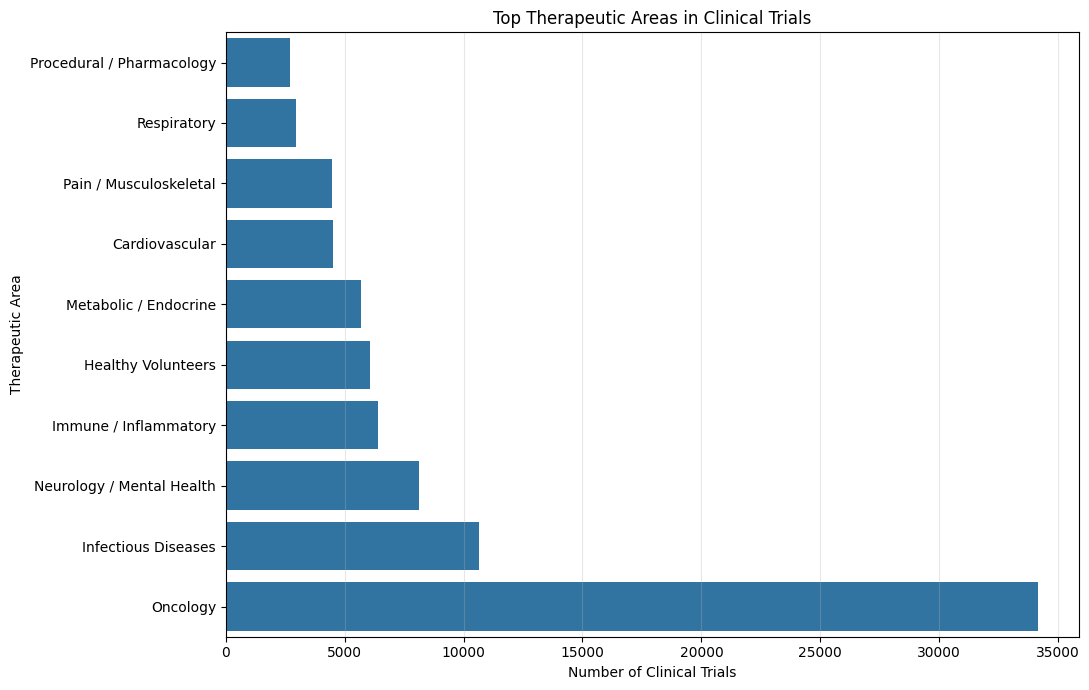

In [41]:
top_therapeutic_areas = (
    therapeutic_area_summary
    .head(10)
    .sort_values("trials")
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_therapeutic_areas,
    x="trials",
    y="therapeutic_area"
)

plt.title("Top Therapeutic Areas in Clinical Trials")
plt.xlabel("Number of Clinical Trials")
plt.ylabel("Therapeutic Area")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Key Insight

Oncology was the most frequently identified therapeutic area, appearing in
34,161 clinical trials, equivalent to 29.90% of the dataset. Infectious
Diseases ranked second at 9.31%, followed by Neurology / Mental Health at
7.13%.

Healthy-volunteer studies accounted for 5.32% and represent a study
population rather than a disease area.

At least one therapeutic area was identified for 77.37% of trials.
Because individual trials may include conditions from multiple therapeutic
areas, these categories are not mutually exclusive.

In [42]:
# Main disease areas, excluding Healthy Volunteers
top_disease_areas = [
    "Oncology",
    "Infectious Diseases",
    "Neurology / Mental Health",
    "Immune / Inflammatory",
    "Metabolic / Endocrine"
]

# Add sponsor category to the trial-area bridge table
trial_area_sponsor = df_trial_areas.merge(
    df_clean[
        ["nct_id", "sponsor_category"]
    ],
    on="nct_id",
    how="left"
)

# Count unique trials by therapeutic area and sponsor
area_sponsor_counts = (
    trial_area_sponsor[
        trial_area_sponsor["therapeutic_area"].isin(
            top_disease_areas
        )
    ]
    .groupby(
        ["therapeutic_area", "sponsor_category"]
    )["nct_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(
        index=top_disease_areas,
        columns=["Industry", "Government", "Other"]
    )
)

# Total trials belonging to each sponsor group
sponsor_totals = (
    df_clean["sponsor_category"]
    .value_counts()
    .reindex(["Industry", "Government", "Other"])
)

# Prevalence of each area within each sponsor's trials
area_sponsor_pct = (
    area_sponsor_counts
    .div(sponsor_totals, axis="columns")
    * 100
).round(2)

area_sponsor_pct

sponsor_category,Industry,Government,Other
therapeutic_area,,,
Oncology,27.04,31.50,31.65
Infectious Diseases,9.20,18.48,8.76
Neurology / Mental Health,6.74,5.78,7.47
Immune / Inflammatory,7.59,3.79,4.41
Metabolic / Endocrine,5.89,3.77,4.47


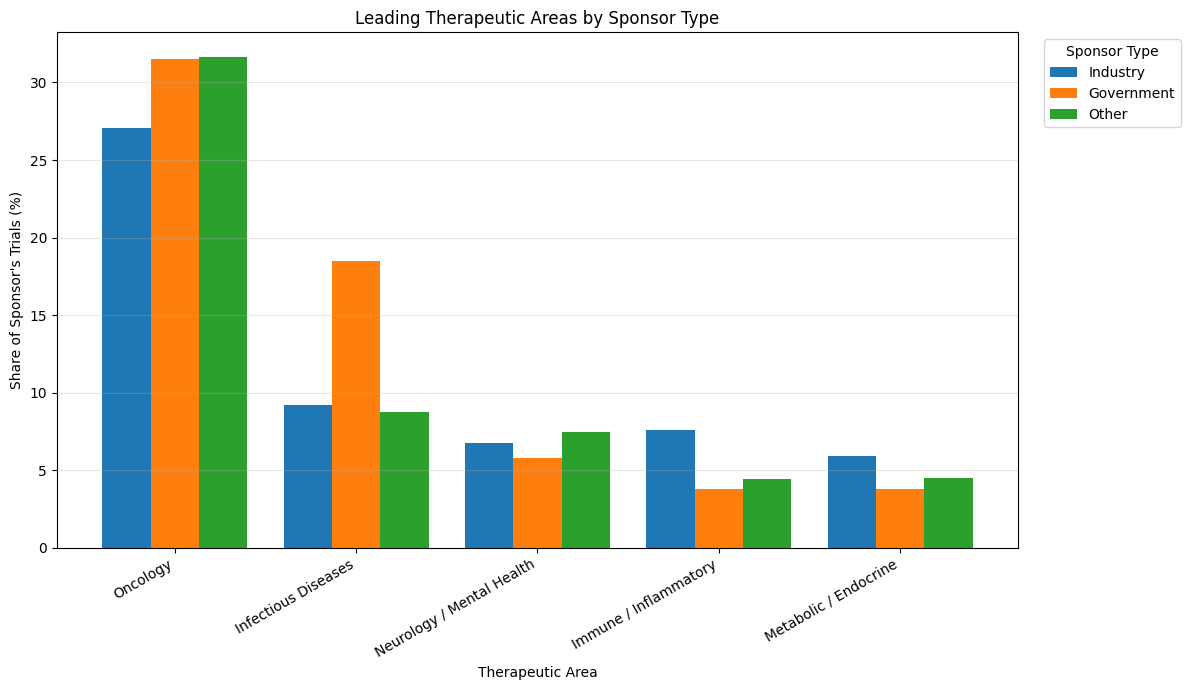

In [43]:
area_sponsor_pct.plot(
    kind="bar",
    figsize=(12, 7),
    width=0.8
)

plt.title("Leading Therapeutic Areas by Sponsor Type")
plt.xlabel("Therapeutic Area")
plt.ylabel("Share of Sponsor's Trials (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="Sponsor Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Sponsor Differences by Therapeutic Area

Oncology was the leading therapeutic area across all sponsor groups,
representing approximately 27–32% of their trials.

Government-sponsored research showed a notably higher relative presence in
Infectious Diseases, which accounted for 18.48% of Government trials,
compared with 9.20% for Industry and 8.76% for Other sponsors.

Industry showed higher relative representation in Immune / Inflammatory
and Metabolic / Endocrine studies, while Other sponsors had the highest
relative share in Neurology / Mental Health.

These comparisons are descriptive, and therapeutic areas are not mutually
exclusive because a single trial may address multiple areas.

## Geographic Distribution of Clinical Trials

Clinical trials may operate in one or multiple countries. This section 
examines their geographic distribution and distinguishes national from 
multinational studies.

In [44]:
# Create one row per trial and country
df_countries = (
    df_clean[
        ["nct_id", "countries"]
    ]
    .dropna(subset=["countries"])
    .assign(
        country=lambda x: x["countries"].str.split(";")
    )
    .explode("country")
)

# Clean country names
df_countries["country"] = (
    df_countries["country"]
    .str.strip()
)

# Remove empty values and duplicate trial-country combinations
df_countries = (
    df_countries[
        df_countries["country"].ne("")
    ]
    .drop_duplicates(
        subset=["nct_id", "country"]
    )
)

countries_per_trial = (
    df_countries
    .groupby("nct_id")["country"]
    .nunique()
)

print("Trial-country records:", len(df_countries))
print("Unique countries:", df_countries["country"].nunique())
print("Trials with country information:", countries_per_trial.size)
print(
    "Trials without country information:",
    df_clean["countries"].isna().sum()
)
print(
    "Multinational trials:",
    (countries_per_trial > 1).sum()
)

Trial-country records: 210932
Unique countries: 187
Trials with country information: 105993
Trials without country information: 8265
Multinational trials: 15140


In [45]:
#clasificaremos cada ensayo como nacional, multinacional o sin información
# Add the number of countries to the main dataset
df_clean["country_count"] = (
    df_clean["nct_id"]
    .map(countries_per_trial)
)

# Classify geographic scope
df_clean["geographic_scope"] = np.select(
    [
        df_clean["country_count"].isna(),
        df_clean["country_count"].eq(1),
        df_clean["country_count"].gt(1)
    ],
    [
        "No Country Information",
        "Single-country",
        "Multinational"
    ],
    default="Unknown"
)

geographic_scope_summary = (
    df_clean["geographic_scope"]
    .value_counts()
    .reindex([
        "Single-country",
        "Multinational",
        "No Country Information"
    ])
    .rename_axis("geographic_scope")
    .reset_index(name="trials")
)

geographic_scope_summary["percentage_of_all_trials"] = (
    geographic_scope_summary["trials"]
    / len(df_clean)
    * 100
).round(2)

geographic_scope_summary

,geographic_scope,trials,percentage_of_all_trials
0,Single-country,90853,79.52
1,Multinational,15140,13.25
2,No Country Information,8265,7.23


In [46]:
trials_with_geography = df_clean[
    df_clean["geographic_scope"].isin([
        "Single-country",
        "Multinational"
    ])
]

geographic_scope_reported_pct = (
    trials_with_geography["geographic_scope"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

geographic_scope_reported_pct

geographic_scope
Single-country    85.72
Multinational     14.28
Name: proportion, dtype: float64

### Geographic Scope

Geographic information was available for 92.77% of clinical trials.

Among trials with reported country information, 85.72% were conducted in a
single country and 14.28% were multinational.

This indicates that most trials with reported geographic information had a
single-country scope.

In [47]:
# Proporción multinacional por patrocinador
# Use only trials with reported geographic information
df_geo_reported = df_clean[
    df_clean["geographic_scope"].isin([
        "Single-country",
        "Multinational"
    ])
]

geo_scope_by_sponsor_counts = pd.crosstab(
    df_geo_reported["sponsor_category"],
    df_geo_reported["geographic_scope"]
).reindex(
    index=["Industry", "Government", "Other"],
    columns=["Single-country", "Multinational"]
)

geo_scope_by_sponsor_pct = (
    pd.crosstab(
        df_geo_reported["sponsor_category"],
        df_geo_reported["geographic_scope"],
        normalize="index"
    ) * 100
).reindex(
    index=["Industry", "Government", "Other"],
    columns=["Single-country", "Multinational"]
).round(2)

geo_scope_by_sponsor_pct

geographic_scope,Single-country,Multinational
sponsor_category,,
Industry,68.66,31.34
Government,91.81,8.19
Other,96.85,3.15


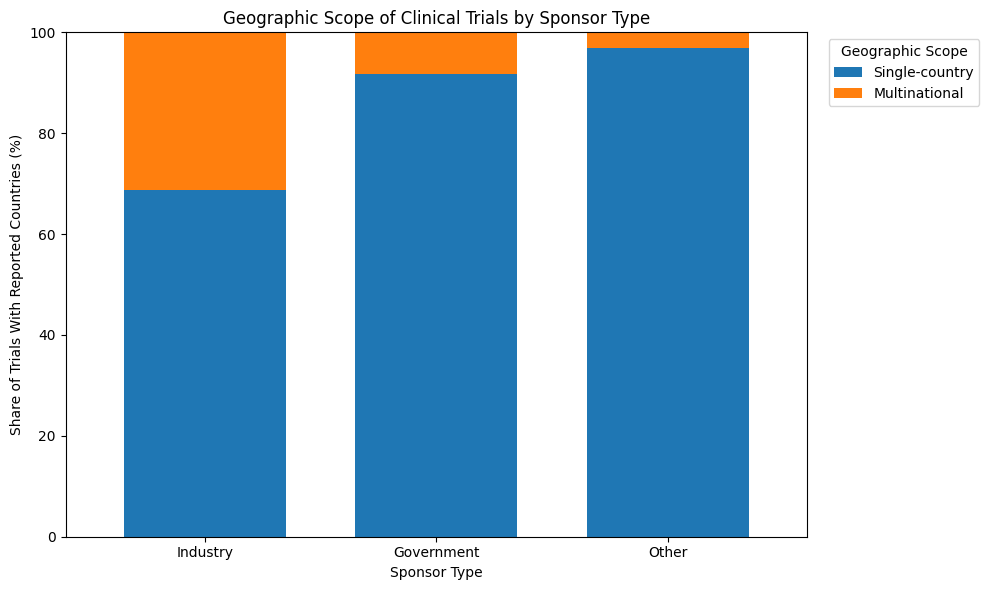

In [48]:
geo_scope_by_sponsor_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.7
)

plt.title("Geographic Scope of Clinical Trials by Sponsor Type")
plt.xlabel("Sponsor Type")
plt.ylabel("Share of Trials With Reported Countries (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Geographic Scope",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Geographic Scope by Sponsor

Industry-sponsored trials showed a substantially higher multinational share.

Among trials with reported country information, 31.34% of Industry studies
were multinational, compared with 8.19% of Government trials and 3.15% of
Other-sponsored trials.

This indicates a distinct geographic pattern across sponsor types, with
Industry trials more frequently involving multiple countries.

In [49]:
country_summary = (
    df_countries["country"]
    .value_counts()
    .rename_axis("country")
    .reset_index(name="trials")
)

country_summary["percentage_of_reported_trials"] = (
    country_summary["trials"]
    / countries_per_trial.size
    * 100
).round(2)

country_summary.head(10)

,country,trials,percentage_of_reported_trials
0,United States,42453,40.05
1,China,22522,21.25
2,France,8225,7.76
3,Canada,7985,7.53
4,Spain,7838,7.39
5,United Kingdom,7589,7.16
6,Germany,7452,7.03
7,South Korea,6518,6.15
8,Italy,6241,5.89
9,Australia,5622,5.30


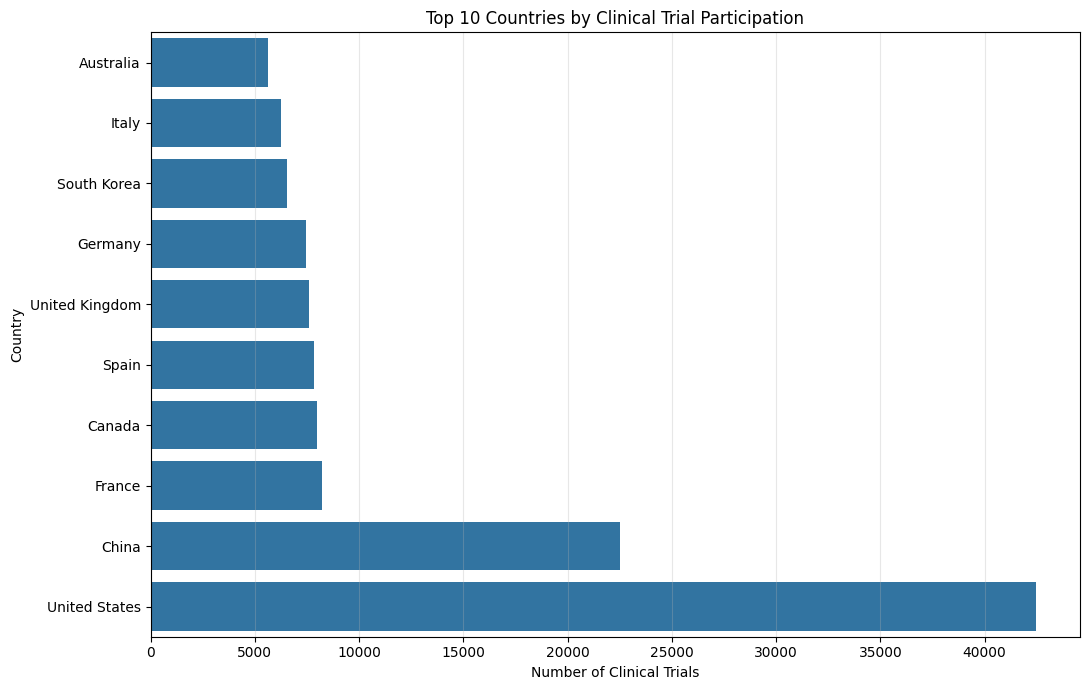

In [50]:
top_countries = (
    country_summary
    .head(10)
    .sort_values("trials")
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_countries,
    x="trials",
    y="country"
)

plt.title("Top 10 Countries by Clinical Trial Participation")
plt.xlabel("Number of Clinical Trials")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Key Insight

The United States was the most frequently reported clinical trial location,
participating in 42,453 trials (40.05% of trials with reported geographic
information), followed by China with 22,522 trials (21.25%).

France, Canada, Spain, the United Kingdom, and Germany each appeared in
approximately 7–8% of trials with reported country information.

Country percentages are not mutually exclusive because multinational trials
are counted once for every participating country. These values represent
trial participation by country, not the number of study sites or enrolled
participants.

## Participant Enrollment Analysis

This section examines reported participant enrollment among completed
clinical trials.

The original enrollment field is preserved, while a separate analytical
field is used to exclude values identified as invalid during data-quality
validation. Trials with missing or non-positive enrollment are excluded from
the main enrollment analysis.

Because the extracted dataset does not preserve the registry's
actual-versus-estimated enrollment indicator, results are interpreted as
reported enrollment counts.

In [51]:
# Preserve the original enrollment and create an analytical version
df_clean["enrollment_clean"] = df_clean["enrollment"].copy()
df_clean["enrollment_quality_flag"] = "Reported"

# Enrollment value identified as invalid during data-quality validation
invalid_enrollment_id = "NCT05438901"

df_clean.loc[
    df_clean["nct_id"] == invalid_enrollment_id,
    "enrollment_clean"
] = np.nan

df_clean.loc[
    df_clean["nct_id"] == invalid_enrollment_id,
    "enrollment_quality_flag"
] = "Invalid registry value"

# Completed trials with valid positive enrollment
df_enrollment_analysis = df_clean[
    (df_clean["overall_status"] == "COMPLETED") &
    (df_clean["enrollment_clean"].notna()) &
    (df_clean["enrollment_clean"] > 0)
].copy()

# Validation counts
completed_trials = (
    df_clean["overall_status"] == "COMPLETED"
)

total_completed = completed_trials.sum()

missing_enrollment = (
    completed_trials &
    df_clean["enrollment"].isna()
).sum()

invalid_enrollment = (
    df_clean["enrollment_quality_flag"] == "Invalid registry value"
).sum()

# Results
print(
    "Total completed trials:",
    f"{total_completed:,}"
)

print(
    "Trials available for enrollment analysis:",
    f"{len(df_enrollment_analysis):,}"
)

print(
    "Completed trials with missing enrollment:",
    f"{missing_enrollment:,}"
)

print(
    "Records excluded as invalid:",
    f"{invalid_enrollment:,}"
)

print("\nEnrollment percentiles:")
print(
    df_enrollment_analysis["enrollment_clean"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

Total completed trials: 51,200
Trials available for enrollment analysis: 51,191
Completed trials with missing enrollment: 8
Records excluded as invalid: 1

Enrollment percentiles:
0.25      27.0
0.50      59.0
0.75     133.0
0.90     349.0
0.95     610.0
0.99    2162.0
Name: enrollment_clean, dtype: float64


### Enrollment Distribution

Reported enrollment was strongly right-skewed. Among completed trials
included in the analysis, median enrollment was 59 participants, with an
interquartile range of 27 to 133 participants.

The 99th percentile was approximately 2,162 participants, indicating that
a relatively small number of very large studies substantially extend the
upper tail of the distribution. Median enrollment is therefore used as the
primary measure of typical study size.

### Enrollment by Clinical Phase

In [52]:
# Enrollment summary by defined clinical phase
enrollment_by_phase = (
    df_enrollment_analysis[
        df_enrollment_analysis["phase_category"].isin(
            clinical_phase_order
        )
    ]
    .groupby("phase_category")["enrollment_clean"]
    .agg(
        studies="count",
        mean_enrollment="mean",
        median_enrollment="median",
        q1_enrollment=lambda x: x.quantile(0.25),
        q3_enrollment=lambda x: x.quantile(0.75)
    )
    .reindex(clinical_phase_order)
    .round(1)
)

enrollment_by_phase

,studies,mean_enrollment,median_enrollment,q1_enrollment,q3_enrollment
phase_category,,,,,
Early Phase 1,1383,48.1,24.0,12.0,52.0
Phase 1,16748,53.5,32.0,18.0,58.0
Phase 2,12272,150.0,62.0,30.0,136.0
Phase 3,7566,848.4,243.0,100.0,520.0
Phase 4,7171,693.6,80.0,40.0,162.0


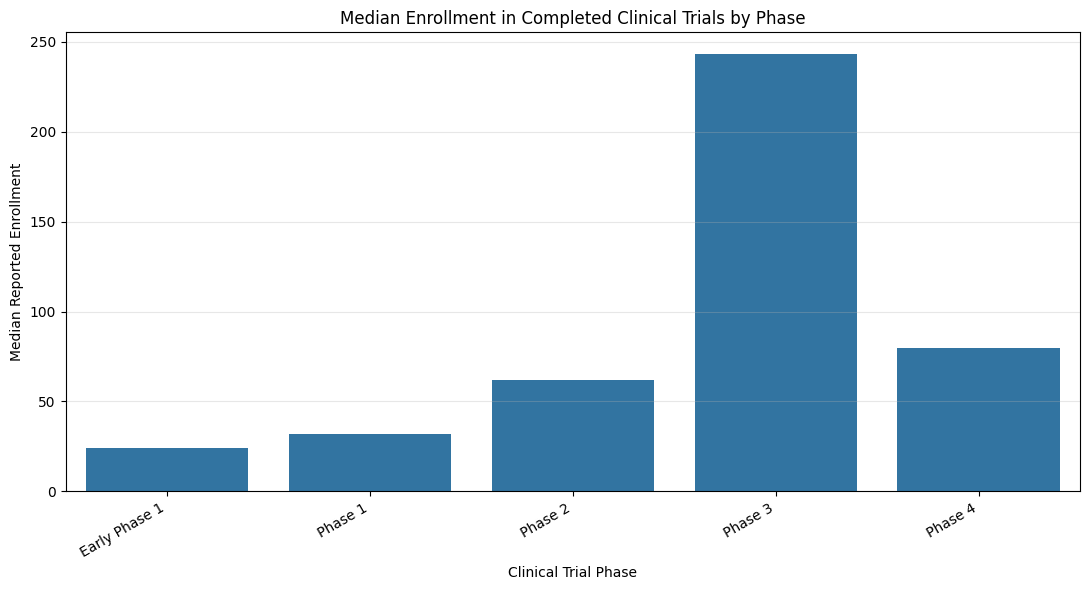

In [53]:
enrollment_phase_plot = (
    enrollment_by_phase
    .reset_index()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=enrollment_phase_plot,
    x="phase_category",
    y="median_enrollment",
    order=clinical_phase_order
)

plt.title("Median Enrollment in Completed Clinical Trials by Phase")
plt.xlabel("Clinical Trial Phase")
plt.ylabel("Median Reported Enrollment")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Key Insight

Median reported enrollment increased from 24 participants in Early Phase 1
and 32 in Phase 1 to 62 in Phase 2 and 243 in Phase 3. Phase 3 therefore
showed the largest typical enrollment among the defined clinical phases.

Phase 4 had a lower median enrollment of 80 participants but a substantially
higher mean of 693.6, indicating a strongly right-skewed distribution with
a relatively small number of very large studies.

Median enrollment was used as the primary measure of typical study size
because enrollment distributions were strongly skewed.

## Intervention Type Analysis

This section classifies clinical trials according to whether they include
drug interventions, biological interventions, or a combination of both.

Repeated intervention labels within the same trial are consolidated into
a single analytical category.

Drug interventions dominated the dataset, appearing without a biological 
intervention in 86.53% of trials. Biological-only interventions represented 
10.29%, while 3.18% combined both drugs and biological products. All studies 
were successfully classified, confirming consistency with the original API 
selection criteria.

In [54]:
# Identify qualifying intervention types within each trial
has_drug = (
    df_clean["intervention_types"]
    .str.contains("DRUG", na=False)
)

has_biological = (
    df_clean["intervention_types"]
    .str.contains("BIOLOGICAL", na=False)
)

# Create simplified intervention categories
df_clean["intervention_category"] = np.select(
    [
        has_drug & has_biological,
        has_drug,
        has_biological
    ],
    [
        "Drug + Biological",
        "Drug",
        "Biological"
    ],
    default="Unclassified"
)

intervention_summary = (
    df_clean["intervention_category"]
    .value_counts()
    .reindex([
        "Drug",
        "Biological",
        "Drug + Biological",
        "Unclassified"
    ])
    .dropna()
    .rename_axis("intervention_category")
    .reset_index(name="trials")
)

intervention_summary["percentage"] = (
    intervention_summary["trials"]
    / len(df_clean)
    * 100
).round(2)

print(
    "Unclassified intervention types:",
    (df_clean["intervention_category"] == "Unclassified").sum()
)

intervention_summary

Unclassified intervention types: 0


,intervention_category,trials,percentage
0,Drug,98866.0,86.53
1,Biological,11754.0,10.29
2,Drug + Biological,3638.0,3.18


In [55]:
intervention_order = [
    "Drug",
    "Biological",
    "Drug + Biological"
]

intervention_by_phase = (
    pd.crosstab(
        df_clean["phase_category"],
        df_clean["intervention_category"],
        normalize="index"
    ) * 100
)

intervention_by_phase = (
    intervention_by_phase
    .reindex(
        index=clinical_phase_order,
        columns=intervention_order
    )
    .round(2)
)

intervention_by_phase

intervention_category,Drug,Biological,Drug + Biological
phase_category,,,
Early Phase 1,81.86,15.55,2.58
Phase 1,79.91,15.40,4.69
Phase 2,88.77,7.35,3.88
Phase 3,87.32,9.69,2.99
Phase 4,93.96,5.35,0.69


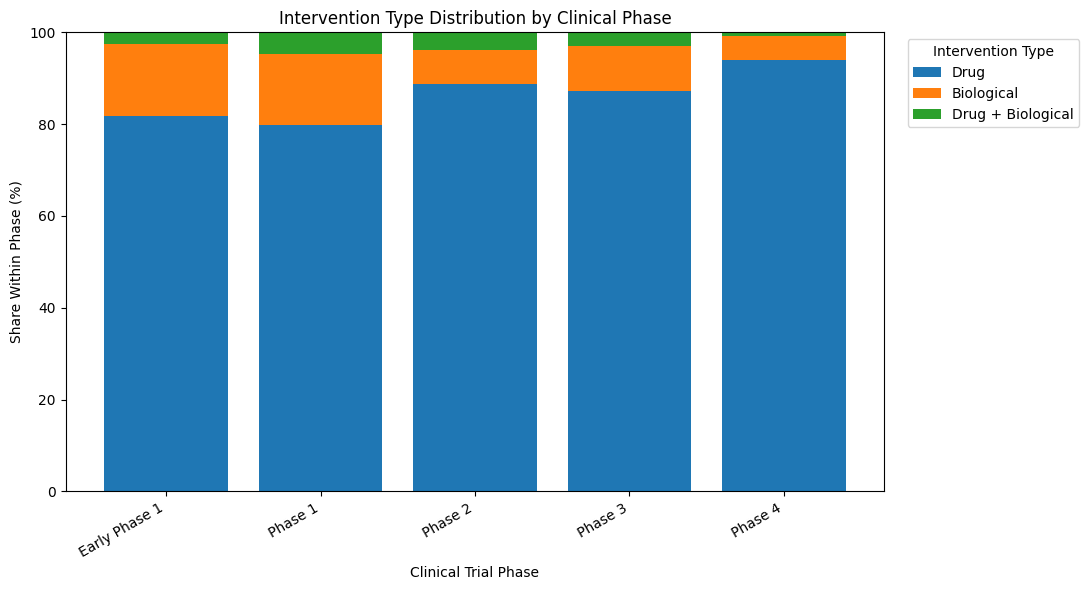

In [56]:
intervention_by_phase.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    width=0.8
)

plt.title("Intervention Type Distribution by Clinical Phase")
plt.xlabel("Clinical Trial Phase")
plt.ylabel("Share Within Phase (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="Intervention Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Key Insight

Drug interventions represented the majority of trials across all defined
clinical phases.

Biological-only interventions had their highest relative representation in
Early Phase 1 and Phase 1, accounting for approximately 15.5% of trials in
both stages. Combined Drug and Biological interventions were also most
frequent in Phase 1, at 4.69%.

Drug-only interventions represented 93.96% of Phase 4 trials, the highest
share observed across the defined clinical phases.

## Analytical Data Model Preparation

The cleaned dataset is organized into one primary trial table and two bridge tables for countries and therapeutic areas.

This structure preserves one row per clinical trial in the main table while supporting many-to-many geographic and therapeutic relationships for SQL and Power BI analysis.

In [57]:
# Add detailed sponsor classification to the complete dataset
detailed_sponsor_map = (
    df_other
    .set_index("nct_id")["detailed_sponsor_category"]
)

df_clean["detailed_sponsor_category"] = np.where(
    df_clean["sponsor_category"] == "Other",
    df_clean["nct_id"].map(detailed_sponsor_map),
    df_clean["sponsor_category"]
)

# Preserve only validated observed durations
df_clean["observed_duration_days"] = np.nan
df_clean["observed_duration_years"] = np.nan

df_clean.loc[
    df_duration_analysis.index,
    "observed_duration_days"
] = df_duration_analysis["duration_days"]

df_clean.loc[
    df_duration_analysis.index,
    "observed_duration_years"
] = df_duration_analysis["duration_years"]

In [58]:
# Main clinical trial table
trial_columns = [
    "nct_id",
    "brief_title",
    "study_type",
    "phase_category",
    "overall_status",
    "status_group",
    "sponsor_name",
    "sponsor_type",
    "sponsor_category",
    "detailed_sponsor_category",
    "start_date",
    "completion_date",
    "start_year",
    "completion_year",
    "future_completion",
    "duration_days",
    "duration_years",
    "observed_duration_days",
    "observed_duration_years",
    "enrollment",
    "enrollment_clean",
    "enrollment_quality_flag",
    "intervention_types",
    "intervention_names",
    "intervention_category",
    "conditions",
    "countries",
    "country_count",
    "geographic_scope"
]

trials_final = df_clean[
    trial_columns
].copy()

In [59]:
# Country bridge table
countries_final = (
    df_countries[
        ["nct_id", "country"]
    ]
    .drop_duplicates()
    .sort_values(["nct_id", "country"])
    .reset_index(drop=True)
)

In [60]:
# Therapeutic-area bridge table

# Keep all defined therapeutic-area relationships
therapeutic_areas_final = df_trial_areas[
    df_trial_areas["therapeutic_area"]
    != "Other / Unclassified"
].copy()

# Trials with conditions but no classified therapeutic area
unclassified_area_rows = pd.DataFrame({
    "nct_id": list(fully_unclassified_ids),
    "therapeutic_area": "Other / Unclassified"
})

# Trials without condition information
missing_condition_rows = pd.DataFrame({
    "nct_id": df_clean.loc[
        df_clean["conditions"].isna(),
        "nct_id"
    ],
    "therapeutic_area": "No Condition Information"
})

therapeutic_areas_final = (
    pd.concat(
        [
            therapeutic_areas_final,
            unclassified_area_rows,
            missing_condition_rows
        ],
        ignore_index=True
    )
    .drop_duplicates()
    .sort_values(["nct_id", "therapeutic_area"])
    .reset_index(drop=True)
)

In [61]:
#Validate analytical tables
print("MAIN TRIAL TABLE")
print("Rows:", len(trials_final))
print("Unique trials:", trials_final["nct_id"].nunique())
print("Duplicate IDs:", trials_final["nct_id"].duplicated().sum())
print(
    "Missing detailed sponsor categories:",
    trials_final["detailed_sponsor_category"].isna().sum()
)

print("\nCOUNTRY BRIDGE TABLE")
print("Rows:", len(countries_final))
print(
    "Duplicate trial-country pairs:",
    countries_final.duplicated(
        ["nct_id", "country"]
    ).sum()
)

print("\nTHERAPEUTIC AREA BRIDGE TABLE")
print("Rows:", len(therapeutic_areas_final))
print(
    "Trials represented:",
    therapeutic_areas_final["nct_id"].nunique()
)
print(
    "Duplicate trial-area pairs:",
    therapeutic_areas_final.duplicated(
        ["nct_id", "therapeutic_area"]
    ).sum()
)

MAIN TRIAL TABLE
Rows: 114258
Unique trials: 114258
Duplicate IDs: 0
Missing detailed sponsor categories: 0

COUNTRY BRIDGE TABLE
Rows: 210932
Duplicate trial-country pairs: 0

THERAPEUTIC AREA BRIDGE TABLE
Rows: 121169
Trials represented: 114258
Duplicate trial-area pairs: 0


In [62]:
# Prepare integer-like columns for export
integer_columns = [
    "start_year",
    "completion_year",
    "duration_days",
    "observed_duration_days",
    "enrollment",
    "enrollment_clean",
    "country_count"
]

for column in integer_columns:
    trials_final[column] = (
        trials_final[column]
        .round()
        .astype("Int64")
    )

# Create processed-data folder
processed_data_folder = Path("data/processed")
processed_data_folder.mkdir(
    parents=True,
    exist_ok=True
)

# Define output paths
trials_path = (
    processed_data_folder
    / "clinical_trials.csv"
)

countries_path = (
    processed_data_folder
    / "trial_countries.csv"
)

areas_path = (
    processed_data_folder
    / "trial_therapeutic_areas.csv"
)

# Export analytical tables
trials_final.to_csv(
    trials_path,
    index=False,
    encoding="utf-8",
    date_format="%Y-%m-%d"
)

countries_final.to_csv(
    countries_path,
    index=False,
    encoding="utf-8"
)

therapeutic_areas_final.to_csv(
    areas_path,
    index=False,
    encoding="utf-8"
)

print("Files exported successfully:\n")

for file_path in [
    trials_path,
    countries_path,
    areas_path
]:
    print(
        file_path,
        "—",
        round(
            file_path.stat().st_size / 1_048_576,
            2
        ),
        "MB"
    )

Files exported successfully:

data/processed/clinical_trials.csv — 48.84 MB
data/processed/trial_countries.csv — 4.31 MB
data/processed/trial_therapeutic_areas.csv — 3.39 MB


In [63]:
export_validation = {
    "clinical_trials": pd.read_csv(
        trials_path,
        low_memory=False
    ).shape,
    
    "trial_countries": pd.read_csv(
        countries_path
    ).shape,
    
    "trial_therapeutic_areas": pd.read_csv(
        areas_path
    ).shape
}

export_validation

{'clinical_trials': (114258, 29),
 'trial_countries': (210932, 2),
 'trial_therapeutic_areas': (121169, 2)}

# SQL Analysis

The processed analytical tables are loaded into PostgreSQL to create a
relational analytical model and independently validate key findings obtained
in Python.

The SQL workflow includes data loading, integrity checks, relational
constraints, joins, aggregations, window functions, and common table
expressions.

In [64]:
# Reload the already processed fixed tables
trials_final = pd.read_csv(
    "data/processed/clinical_trials.csv",
    low_memory=False,
    parse_dates=["start_date", "completion_date"]
)

countries_final = pd.read_csv(
    "data/processed/trial_countries.csv"
)

therapeutic_areas_final = pd.read_csv(
    "data/processed/trial_therapeutic_areas.csv"
)

print("Clinical trials:", trials_final.shape)
print("Trial countries:", countries_final.shape)
print("Therapeutic areas:", therapeutic_areas_final.shape)

Clinical trials: (114258, 29)
Trial countries: (210932, 2)
Therapeutic areas: (121169, 2)


In [ ]:
import os

from dotenv import load_dotenv
from sqlalchemy import create_engine, text, URL

# Load local PostgreSQL configuration
load_dotenv()

db_user = os.getenv("POSTGRES_USER")
db_password = os.getenv("POSTGRES_PASSWORD") or None
db_host = os.getenv("POSTGRES_HOST", "localhost")
db_port = int(os.getenv("POSTGRES_PORT", "5432"))
db_name = os.getenv("POSTGRES_DB")

if not db_user or not db_name:
    raise RuntimeError(
        "PostgreSQL credentials are not configured. "
        "Create a local .env file using .env.example as reference."
    )

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=db_user,
    password=db_password,
    host=db_host,
    port=db_port,
    database=db_name
)

engine = create_engine(connection_url)

# Test connection and create project schema
with engine.begin() as connection:
    postgres_version = connection.execute(
        text("SELECT version();")
    ).scalar()

    connection.execute(
        text(
            "CREATE SCHEMA IF NOT EXISTS pharma_trials;"
        )
    )

print("PostgreSQL connection successful")
print(postgres_version)
print("Schema ready: pharma_trials")

In [66]:
from sqlalchemy import types as sqltypes

# Confirm that the expected processed tables are loaded
assert trials_final.shape == (114258, 29)
assert countries_final.shape == (210932, 2)
assert therapeutic_areas_final.shape == (121169, 2)

# Restore appropriate data types after reading the CSV files
date_columns = ["start_date", "completion_date"]

for column in date_columns:
    trials_final[column] = pd.to_datetime(
        trials_final[column],
        errors="coerce"
    )

integer_columns = [
    "start_year",
    "completion_year",
    "duration_days",
    "observed_duration_days",
    "enrollment",
    "enrollment_clean",
    "country_count"
]

for column in integer_columns:
    trials_final[column] = pd.to_numeric(
        trials_final[column],
        errors="coerce"
    ).astype("Int64")

trials_final["future_completion"] = (
    trials_final["future_completion"]
    .astype("string")
    .str.lower()
    .map({
        "true": True,
        "false": False,
        "1": True,
        "0": False
    })
    .astype("boolean")
)

# Explicit PostgreSQL data types
clinical_trials_dtypes = {
    "nct_id": sqltypes.Text(),
    "brief_title": sqltypes.Text(),
    "study_type": sqltypes.Text(),
    "phase_category": sqltypes.Text(),
    "overall_status": sqltypes.Text(),
    "status_group": sqltypes.Text(),
    "sponsor_name": sqltypes.Text(),
    "sponsor_type": sqltypes.Text(),
    "sponsor_category": sqltypes.Text(),
    "detailed_sponsor_category": sqltypes.Text(),
    "start_date": sqltypes.Date(),
    "completion_date": sqltypes.Date(),
    "start_year": sqltypes.BigInteger(),
    "completion_year": sqltypes.BigInteger(),
    "future_completion": sqltypes.Boolean(),
    "duration_days": sqltypes.BigInteger(),
    "duration_years": sqltypes.Float(),
    "observed_duration_days": sqltypes.BigInteger(),
    "observed_duration_years": sqltypes.Float(),
    "enrollment": sqltypes.BigInteger(),
    "enrollment_clean": sqltypes.BigInteger(),
    "enrollment_quality_flag": sqltypes.Text(),
    "intervention_types": sqltypes.Text(),
    "intervention_names": sqltypes.Text(),
    "intervention_category": sqltypes.Text(),
    "conditions": sqltypes.Text(),
    "countries": sqltypes.Text(),
    "country_count": sqltypes.BigInteger(),
    "geographic_scope": sqltypes.Text()
}

# Remove previous project tables before rebuilding the SQL model
with engine.begin() as connection:
    connection.execute(
        text(
            "DROP TABLE IF EXISTS "
            "pharma_trials.trial_countries;"
        )
    )

    connection.execute(
        text(
            "DROP TABLE IF EXISTS "
            "pharma_trials.trial_therapeutic_areas;"
        )
    )

    connection.execute(
        text(
            "DROP TABLE IF EXISTS "
            "pharma_trials.clinical_trials;"
        )
    )
    
# Load all three tables in one transaction
with engine.begin() as connection:

    trials_final.to_sql(
        name="clinical_trials",
        con=connection,
        schema="pharma_trials",
        if_exists="replace",
        index=False,
        dtype=clinical_trials_dtypes,
        chunksize=1000,
        method="multi"
    )

    countries_final.to_sql(
        name="trial_countries",
        con=connection,
        schema="pharma_trials",
        if_exists="replace",
        index=False,
        dtype={
            "nct_id": sqltypes.Text(),
            "country": sqltypes.Text()
        },
        chunksize=5000,
        method="multi"
    )

    therapeutic_areas_final.to_sql(
        name="trial_therapeutic_areas",
        con=connection,
        schema="pharma_trials",
        if_exists="replace",
        index=False,
        dtype={
            "nct_id": sqltypes.Text(),
            "therapeutic_area": sqltypes.Text()
        },
        chunksize=5000,
        method="multi"
    )

print("All tables loaded successfully into PostgreSQL.")

All tables loaded successfully into PostgreSQL.


In [67]:
# 1. Row counts and unique trials
table_validation_query = text("""
    SELECT
        'clinical_trials' AS table_name,
        COUNT(*) AS total_rows,
        COUNT(DISTINCT nct_id) AS unique_trials
    FROM pharma_trials.clinical_trials

    UNION ALL

    SELECT
        'trial_countries',
        COUNT(*),
        COUNT(DISTINCT nct_id)
    FROM pharma_trials.trial_countries

    UNION ALL

    SELECT
        'trial_therapeutic_areas',
        COUNT(*),
        COUNT(DISTINCT nct_id)
    FROM pharma_trials.trial_therapeutic_areas;
""")

table_validation = pd.read_sql(
    table_validation_query,
    engine
)

table_validation

,table_name,total_rows,unique_trials
0,trial_therapeutic_areas,121169,114258
1,trial_countries,210932,105993
2,clinical_trials,114258,114258


In [68]:
relationship_validation_query = text("""
    SELECT
        'Duplicate trial-country pairs' AS validation,
        COUNT(*) AS issues
    FROM (
        SELECT nct_id, country
        FROM pharma_trials.trial_countries
        GROUP BY nct_id, country
        HAVING COUNT(*) > 1
    ) AS duplicates

    UNION ALL

    SELECT
        'Duplicate trial-area pairs',
        COUNT(*)
    FROM (
        SELECT nct_id, therapeutic_area
        FROM pharma_trials.trial_therapeutic_areas
        GROUP BY nct_id, therapeutic_area
        HAVING COUNT(*) > 1
    ) AS duplicates

    UNION ALL

    SELECT
        'Countries without matching trial',
        COUNT(*)
    FROM pharma_trials.trial_countries AS countries
    LEFT JOIN pharma_trials.clinical_trials AS trials
        ON countries.nct_id = trials.nct_id
    WHERE trials.nct_id IS NULL

    UNION ALL

    SELECT
        'Areas without matching trial',
        COUNT(*)
    FROM pharma_trials.trial_therapeutic_areas AS areas
    LEFT JOIN pharma_trials.clinical_trials AS trials
        ON areas.nct_id = trials.nct_id
    WHERE trials.nct_id IS NULL;
""")

relationship_validation = pd.read_sql(
    relationship_validation_query,
    engine
)

relationship_validation

,validation,issues
0,Duplicate trial-area pairs,0
1,Duplicate trial-country pairs,0
2,Areas without matching trial,0
3,Countries without matching trial,0


In [69]:
database_structure_sql = text("""
DO $$
BEGIN
    -- Primary key: main table
    IF NOT EXISTS (
        SELECT 1
        FROM pg_constraint
        WHERE conname = 'pk_clinical_trials'
          AND conrelid = 'pharma_trials.clinical_trials'::regclass
    ) THEN
        ALTER TABLE pharma_trials.clinical_trials
        ADD CONSTRAINT pk_clinical_trials
        PRIMARY KEY (nct_id);
    END IF;

    -- Composite primary key: countries
    IF NOT EXISTS (
        SELECT 1
        FROM pg_constraint
        WHERE conname = 'pk_trial_countries'
          AND conrelid = 'pharma_trials.trial_countries'::regclass
    ) THEN
        ALTER TABLE pharma_trials.trial_countries
        ADD CONSTRAINT pk_trial_countries
        PRIMARY KEY (nct_id, country);
    END IF;

    -- Composite primary key: therapeutic areas
    IF NOT EXISTS (
        SELECT 1
        FROM pg_constraint
        WHERE conname = 'pk_trial_therapeutic_areas'
          AND conrelid = 'pharma_trials.trial_therapeutic_areas'::regclass
    ) THEN
        ALTER TABLE pharma_trials.trial_therapeutic_areas
        ADD CONSTRAINT pk_trial_therapeutic_areas
        PRIMARY KEY (nct_id, therapeutic_area);
    END IF;

    -- Foreign key: countries to trials
    IF NOT EXISTS (
        SELECT 1
        FROM pg_constraint
        WHERE conname = 'fk_trial_countries_nct'
          AND conrelid = 'pharma_trials.trial_countries'::regclass
    ) THEN
        ALTER TABLE pharma_trials.trial_countries
        ADD CONSTRAINT fk_trial_countries_nct
        FOREIGN KEY (nct_id)
        REFERENCES pharma_trials.clinical_trials (nct_id);
    END IF;

    -- Foreign key: therapeutic areas to trials
    IF NOT EXISTS (
        SELECT 1
        FROM pg_constraint
        WHERE conname = 'fk_trial_areas_nct'
          AND conrelid = 'pharma_trials.trial_therapeutic_areas'::regclass
    ) THEN
        ALTER TABLE pharma_trials.trial_therapeutic_areas
        ADD CONSTRAINT fk_trial_areas_nct
        FOREIGN KEY (nct_id)
        REFERENCES pharma_trials.clinical_trials (nct_id);
    END IF;
END
$$;

CREATE INDEX IF NOT EXISTS idx_trials_start_year
ON pharma_trials.clinical_trials (start_year);

CREATE INDEX IF NOT EXISTS idx_trials_sponsor
ON pharma_trials.clinical_trials (sponsor_category);

CREATE INDEX IF NOT EXISTS idx_trials_phase
ON pharma_trials.clinical_trials (phase_category);

CREATE INDEX IF NOT EXISTS idx_trials_status
ON pharma_trials.clinical_trials (status_group);

CREATE INDEX IF NOT EXISTS idx_countries_country
ON pharma_trials.trial_countries (country);

CREATE INDEX IF NOT EXISTS idx_areas_therapeutic_area
ON pharma_trials.trial_therapeutic_areas (therapeutic_area);
""")

with engine.begin() as connection:
    connection.execute(database_structure_sql)

print("Database constraints and indexes created successfully.")

Database constraints and indexes created successfully.


In [70]:
constraints_query = text("""
    SELECT
        table_name,
        constraint_name,
        constraint_type
    FROM information_schema.table_constraints
    WHERE table_schema = 'pharma_trials'
      AND constraint_type IN (
          'PRIMARY KEY',
          'FOREIGN KEY'
      )
    ORDER BY table_name, constraint_type DESC;
""")

constraints = pd.read_sql(
    constraints_query,
    engine
)

constraints

,table_name,constraint_name,constraint_type
0,clinical_trials,pk_clinical_trials,PRIMARY KEY
1,trial_countries,pk_trial_countries,PRIMARY KEY
2,trial_countries,fk_trial_countries_nct,FOREIGN KEY
3,trial_therapeutic_areas,pk_trial_therapeutic_areas,PRIMARY KEY
4,trial_therapeutic_areas,fk_trial_areas_nct,FOREIGN KEY


### 1. Clinical Trial Portfolio by Sponsor

This query calculates the number and percentage of clinical trials associated with each major sponsor category.

In [71]:
sponsor_summary_query = text("""
    SELECT
        sponsor_category,
        COUNT(*) AS studies,
        ROUND(
            COUNT(*) * 100.0 /
            SUM(COUNT(*)) OVER (),
            2
        ) AS percentage
    FROM pharma_trials.clinical_trials
    GROUP BY sponsor_category
    ORDER BY studies DESC;
""")

sql_sponsor_summary = pd.read_sql(
    sponsor_summary_query,
    engine
)

sql_sponsor_summary

,sponsor_category,studies,percentage
0,Other,66502,58.20
1,Industry,43276,37.88
2,Government,4480,3.92


**Key finding.** Other sponsors account for the largest share of the clinical trial portfolio (58.20%), followed by Industry (37.88%) and Government (3.92%). The broad Other category should not be interpreted as unknown sponsorship, since the detailed classification showed that it consists primarily of academic institutions, hospitals, and research institutes.

### 2. Clinical Phase Distribution by Sponsor

This analysis compares how each sponsor category distributes its clinical
trial portfolio across defined clinical development phases. Trials without
a reported clinical phase are excluded from this phase-specific comparison.
Percentages are calculated independently within each sponsor category.

In [72]:
#distribución de fases dentro del portafolio de cada patrocinador.
phase_sponsor_query = text("""
    WITH phase_counts AS (
        SELECT
            sponsor_category,
            phase_category,
            COUNT(*) AS studies
        FROM pharma_trials.clinical_trials
        WHERE phase_category IN (
            'Early Phase 1',
            'Phase 1',
            'Phase 2',
            'Phase 3',
            'Phase 4'
        )
        GROUP BY
            sponsor_category,
            phase_category
    )

    SELECT
        sponsor_category,
        phase_category,
        studies,
        ROUND(
            studies * 100.0 /
            SUM(studies) OVER (
                PARTITION BY sponsor_category
            ),
            2
        ) AS percentage_within_sponsor
    FROM phase_counts
    ORDER BY
        CASE sponsor_category
            WHEN 'Industry' THEN 1
            WHEN 'Government' THEN 2
            WHEN 'Other' THEN 3
        END,
        CASE phase_category
            WHEN 'Early Phase 1' THEN 1
            WHEN 'Phase 1' THEN 2
            WHEN 'Phase 2' THEN 3
            WHEN 'Phase 3' THEN 4
            WHEN 'Phase 4' THEN 5
        END;
""")

sql_phase_sponsor = pd.read_sql(
    phase_sponsor_query,
    engine
)

sql_phase_sponsor

,sponsor_category,phase_category,studies,percentage_within_sponsor
0,Industry,Early Phase 1,426,1.00
1,Industry,Phase 1,20307,47.77
2,Industry,Phase 2,10761,25.32
3,Industry,Phase 3,9143,21.51
4,Industry,Phase 4,1871,4.40
5,Government,Early Phase 1,125,3.29
6,Government,Phase 1,1101,28.96
7,Government,Phase 2,1457,38.32
8,Government,Phase 3,475,12.49
9,Government,Phase 4,644,16.94


### 3. Known Final Outcomes by Sponsor

This query compares completed and discontinued trials among studies with a
known final outcome.

In [73]:
final_outcomes_query = text("""
    SELECT
        sponsor_category,

        COUNT(*) FILTER (
            WHERE status_group = 'Completed'
        ) AS completed_trials,

        COUNT(*) FILTER (
            WHERE status_group = 'Discontinued'
        ) AS discontinued_trials,

        ROUND(
            100.0 *
            (
                COUNT(*) FILTER (
                    WHERE status_group = 'Completed'
                )
            ) / COUNT(*),
            2
        ) AS completion_rate,

        ROUND(
            100.0 *
            (
                COUNT(*) FILTER (
                    WHERE status_group = 'Discontinued'
                )
            ) / COUNT(*),
            2
        ) AS discontinuation_rate

    FROM pharma_trials.clinical_trials

    WHERE status_group IN (
        'Completed',
        'Discontinued'
    )

    GROUP BY sponsor_category
    ORDER BY completion_rate DESC;
""")

sql_final_outcomes = pd.read_sql(
    final_outcomes_query,
    engine
)

sql_final_outcomes

,sponsor_category,completed_trials,discontinued_trials,completion_rate,discontinuation_rate
0,Industry,24533,6135,80.00,20.00
1,Government,1780,461,79.43,20.57
2,Other,24887,8022,75.62,24.38


### Key Insight

Among trials with a known final outcome, Industry and Government-sponsored
studies showed similar completion rates, at 80.00% and 79.43%, respectively.

Other-sponsored trials had a lower completion rate of 75.62% and a higher
discontinuation rate of 24.38%.

These comparisons are descriptive and may reflect differences in clinical
phase, therapeutic area, study design, and reporting practices rather than
a direct sponsor effect.

### 4. Enrollment and Duration by Clinical Phase

This query compares reported enrollment and observed duration across defined
clinical development phases among completed trials.

Median values are emphasized because both enrollment and duration distributions
can be affected by highly skewed observations.

In [74]:
phase_metrics_query = text("""
    SELECT
        phase_category,

        COUNT(*) FILTER (
            WHERE enrollment_clean > 0
        ) AS studies_with_enrollment,

        ROUND(
            AVG(enrollment_clean) FILTER (
                WHERE enrollment_clean > 0
            ),
            1
        ) AS mean_enrollment,

        ROUND(
            (
                PERCENTILE_CONT(0.5)
                WITHIN GROUP (
                    ORDER BY enrollment_clean
                )
                FILTER (
                    WHERE enrollment_clean > 0
                )
            )::numeric,
            1
        ) AS median_enrollment,

        COUNT(observed_duration_years)
            AS studies_with_duration,

        ROUND(
            (
                PERCENTILE_CONT(0.5)
                WITHIN GROUP (
                    ORDER BY observed_duration_years
                )
                FILTER (
                    WHERE observed_duration_years IS NOT NULL
                )
            )::numeric,
            2
        ) AS median_duration_years

    FROM pharma_trials.clinical_trials

    WHERE
        status_group = 'Completed'
        AND phase_category IN (
            'Early Phase 1',
            'Phase 1',
            'Phase 2',
            'Phase 3',
            'Phase 4'
        )

    GROUP BY phase_category

    ORDER BY
        CASE phase_category
            WHEN 'Early Phase 1' THEN 1
            WHEN 'Phase 1' THEN 2
            WHEN 'Phase 2' THEN 3
            WHEN 'Phase 3' THEN 4
            WHEN 'Phase 4' THEN 5
        END;
""")

sql_phase_metrics = pd.read_sql(
    phase_metrics_query,
    engine
)

sql_phase_metrics

,phase_category,studies_with_enrollment,mean_enrollment,median_enrollment,studies_with_duration,median_duration_years
0,Early Phase 1,1383,48.1,24.0,1382,1.72
1,Phase 1,16748,53.5,32.0,16695,0.97
2,Phase 2,12272,150.0,62.0,12261,2.10
3,Phase 3,7566,848.4,243.0,7559,1.99
4,Phase 4,7171,693.6,80.0,7159,1.65


### Key Insight

Phase 3 trials had the largest median reported enrollment, at 243 participants.

Phase 2 trials had the longest median observed duration, at 2.10 years,
followed by Phase 3 at 1.99 years.

Mean enrollment was substantially higher than the median in several phases,
indicating right-skewed enrollment distributions. Median values therefore
provide a more representative measure of typical trial size.

### 5. Leading Therapeutic Areas

This query uses the therapeutic-area bridge table to identify the most
frequently represented therapeutic areas across clinical trials.

Because a trial may belong to more than one therapeutic area, percentages
are not mutually exclusive.

In [75]:
top_therapeutic_areas_query = text("""
    SELECT
        areas.therapeutic_area,

        COUNT(
            DISTINCT trials.nct_id
        ) AS trials,

        ROUND(
            COUNT(DISTINCT trials.nct_id) * 100.0 /
            (
                SELECT COUNT(*)
                FROM pharma_trials.clinical_trials
            ),
            2
        ) AS percentage_of_all_trials

    FROM pharma_trials.trial_therapeutic_areas AS areas

    INNER JOIN pharma_trials.clinical_trials AS trials
        ON areas.nct_id = trials.nct_id

    WHERE areas.therapeutic_area NOT IN (
        'Other / Unclassified',
        'No Condition Information'
    )

    GROUP BY areas.therapeutic_area
    ORDER BY trials DESC
    LIMIT 10;
""")

sql_top_therapeutic_areas = pd.read_sql(
    top_therapeutic_areas_query,
    engine
)

sql_top_therapeutic_areas

,therapeutic_area,trials,percentage_of_all_trials
0,Oncology,34161,29.90
1,Infectious Diseases,10636,9.31
2,Neurology / Mental Health,8142,7.13
3,Immune / Inflammatory,6391,5.59
4,Healthy Volunteers,6083,5.32
5,Metabolic / Endocrine,5690,4.98
6,Cardiovascular,4499,3.94
7,Pain / Musculoskeletal,4467,3.91
8,Respiratory,2952,2.58
9,Procedural / Pharmacology,2703,2.37


### Key Insight

Oncology was the most frequently represented therapeutic area, appearing in
34,161 trials, equivalent to 29.90% of all studies in the dataset.

Infectious Diseases was the second most common area at 9.31%, followed by
Neurology / Mental Health at 7.13%.

Because individual trials may be associated with more than one therapeutic
area, these percentages are not mutually exclusive and should not be expected
to sum to 100%.

### 6. Geographic Scope by Sponsor

This query compares the geographic scope of trials across sponsor categories.

Only trials with reported geographic information are included, allowing a
direct comparison between single-country and multinational studies within
each sponsor type.

In [76]:
geographic_scope_query = text("""
    SELECT
        sponsor_category,

        COUNT(*) FILTER (
            WHERE geographic_scope = 'Single-country'
        ) AS single_country_trials,

        COUNT(*) FILTER (
            WHERE geographic_scope = 'Multinational'
        ) AS multinational_trials,

        ROUND(
            100.0 *
            (
                COUNT(*) FILTER (
                    WHERE geographic_scope = 'Single-country'
                )
            ) / COUNT(*),
            2
        ) AS single_country_percentage,

        ROUND(
            100.0 *
            (
                COUNT(*) FILTER (
                    WHERE geographic_scope = 'Multinational'
                )
            ) / COUNT(*),
            2
        ) AS multinational_percentage

    FROM pharma_trials.clinical_trials

    WHERE geographic_scope IN (
        'Single-country',
        'Multinational'
    )

    GROUP BY sponsor_category
    ORDER BY multinational_percentage DESC;
""")

sql_geographic_scope = pd.read_sql(
    geographic_scope_query,
    engine
)

sql_geographic_scope

,sponsor_category,single_country_trials,multinational_trials,single_country_percentage,multinational_percentage
0,Industry,28241,12888,68.66,31.34
1,Government,3798,339,91.81,8.19
2,Other,58814,1913,96.85,3.15


### Key Insight

Industry-sponsored trials showed the highest multinational share, with
31.34% conducted across multiple countries.

The corresponding multinational shares were 8.19% for Government-sponsored
trials and 3.15% for Other-sponsored trials.

These results describe a clear difference in geographic scope across sponsor
types within this dataset, without implying that sponsor type itself causes
the observed pattern.

## SQL Analysis Summary

The PostgreSQL analysis reproduced and validated the principal findings
obtained in Python using a normalized relational data model.

Key findings included:

- Other sponsors represented the largest share of the clinical trial
  portfolio.
- Industry and Government-sponsored trials showed similar completion rates
  among studies with known final outcomes, while Other sponsors had a higher
  discontinuation rate.
- Industry trials were concentrated in Phase 1, whereas Government and Other
  sponsors showed their largest shares in Phase 2.
- Phase 3 trials had the largest median enrollment, while Phase 2 had the
  longest median observed duration among the defined clinical phases.
- Oncology was the most frequently represented therapeutic area.
- Industry-sponsored trials had a substantially higher multinational share
  than Government and Other-sponsored trials.

The relational model connected trial-level information with multiple
countries and therapeutic areas while preserving one record per clinical
trial in the main table.

SQL was used not only to reproduce analytical results, but also to validate
data integrity through primary keys, foreign keys, duplicate checks, and
referential-integrity checks.